In [ ]:
#!pip install pandas numpy matplotlib scikit-learn seaborn kagglehub statsmodels
#!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.7 MB/s eta 0:00:00


## **PRELOADS & CONFIGURATION**

In [ ]:
# PRELOADS
import sys
sys.dont_write_bytecode = True

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# CONFIGURATION
mpl.rcParams['figure.dpi'] = 100
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
warnings.filterwarnings("ignore")

## **DATASET LOADING & CORRECTION**

In [ ]:
# Load dataset
econ = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "utkarshx27/us-economic-time-series", "economics.csv")

econ = econ.drop(columns="Unnamed: 0")  # Drop the dummy column.
econ['date'] = pd.to_datetime(econ['date'], format='mixed')  # datetime conversion
econ['pop'] = econ['pop'].astype(int)  # population must be integer
econ['unemploy'] = econ['unemploy'].astype(int)  # unemployees must be integer

100%|██████████| 24.9k/24.9k [00:00<00:00, 41.1MB/s]


## **DATASET OVERVIEW**

In [ ]:
# First Inspections

print(f"Rows: {econ.shape[0]}; Columns: {econ.shape[1]}"); print('='*200)
print(f"Missing values:\n{econ.isnull().sum()}"); print('='*200)
print(econ.info()); print('='*200)
print(econ.describe()); print('='*200)
display(econ.head(10))

Rows: 574; Columns: 6
Missing values:
date        0
pce         0
pop         0
psavert     0
uempmed     0
unemploy    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      574 non-null    datetime64[ns]
 1   pce       574 non-null    float64       
 2   pop       574 non-null    int64         
 3   psavert   574 non-null    float64       
 4   uempmed   574 non-null    float64       
 5   unemploy  574 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 27.0 KB
None
                                date           pce            pop     psavert  \
count                            574    574.000000     574.000000  574.000000   
mean   1991-05-17 09:34:29.686411136   4820.092683  257159.602787    8.567247   
min              1967-07-01 00:00:00    506.700000  198712.000000    2.2000

,date,pce,pop,psavert,uempmed,unemploy
0,1967-07-01,506.7,198712,12.6,4.5,2944
1,1967-08-01,509.8,198911,12.6,4.7,2945
2,1967-09-01,515.6,199113,11.9,4.6,2958
3,1967-10-01,512.2,199311,12.9,4.9,3143
4,1967-11-01,517.4,199498,12.8,4.7,3066
5,1967-12-01,525.1,199657,11.8,4.8,3018
6,1968-01-01,530.9,199808,11.7,5.1,2878
7,1968-02-01,533.6,199920,12.3,4.5,3001
8,1968-03-01,544.3,200056,11.7,4.1,2877
9,1968-04-01,544.0,200208,12.3,4.6,2709


## **FIRST PLOTS**

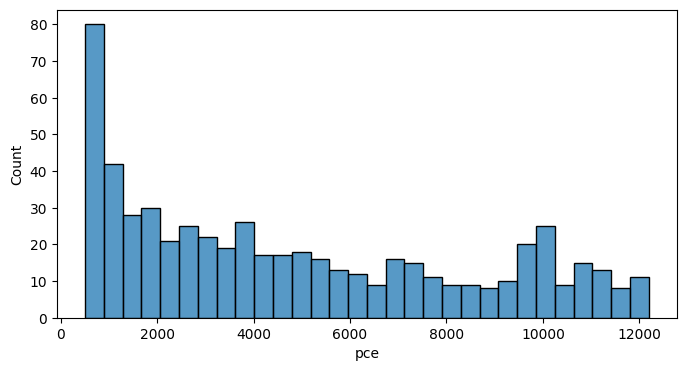

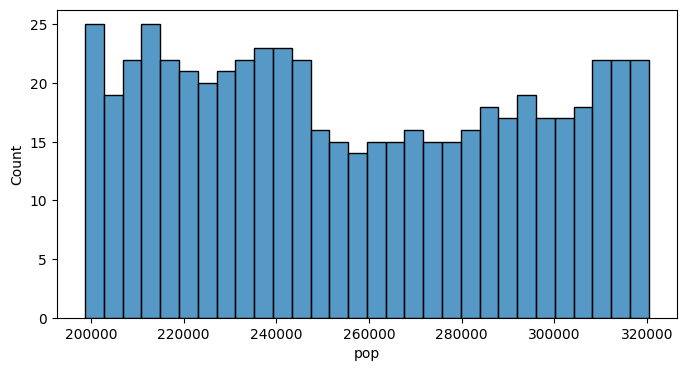

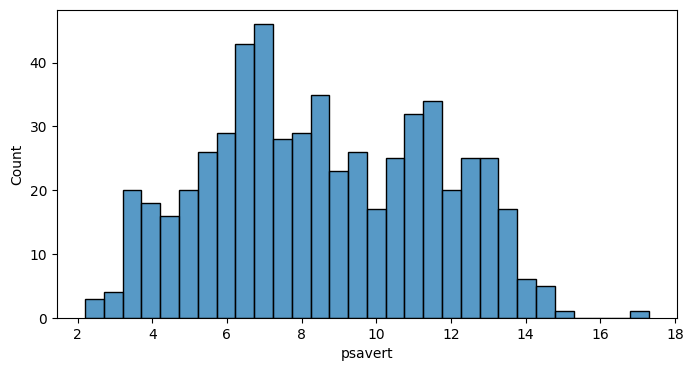

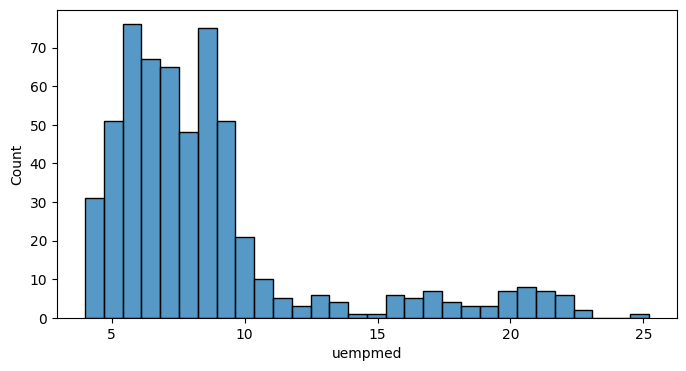

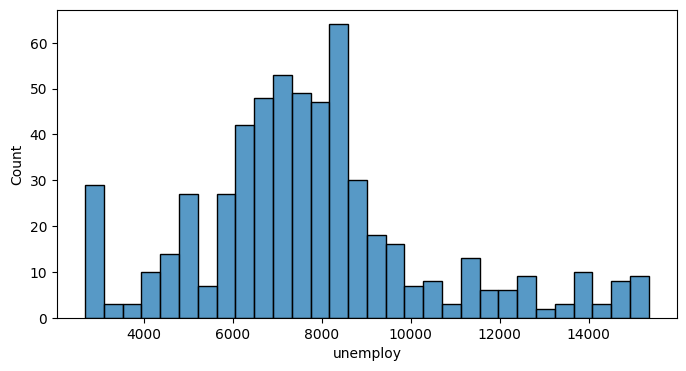

In [ ]:
# Histograms: Data frequency

for c in econ.columns[1:]:
  plt.figure(figsize=(8,4))
  sns.histplot(data=econ, x=c, bins=30)
  plt.show()

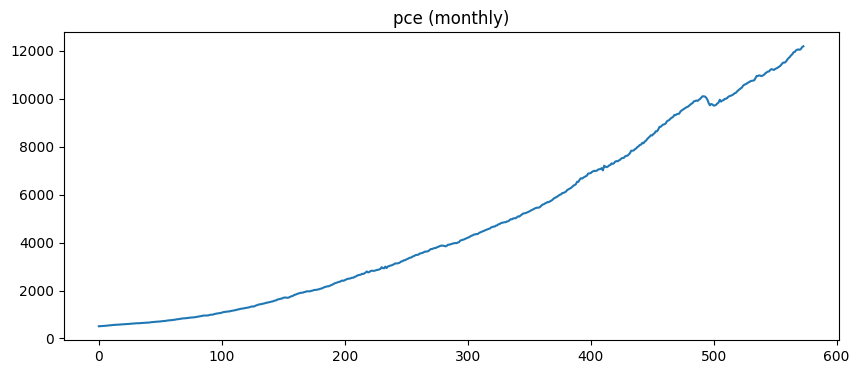

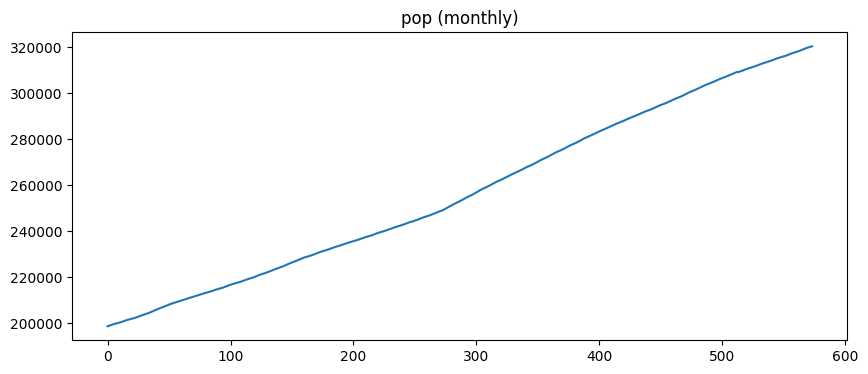

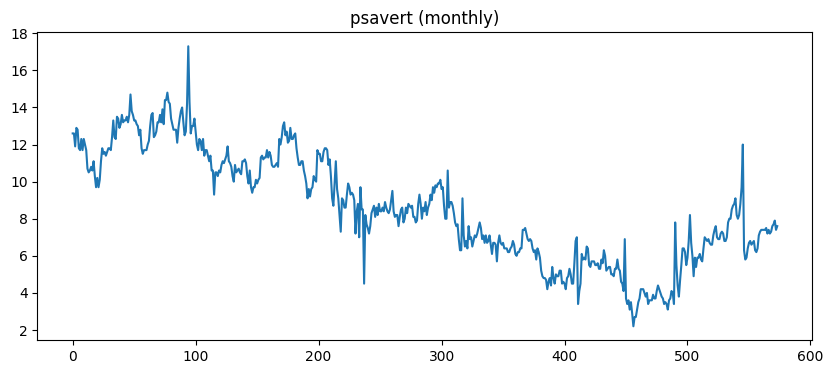

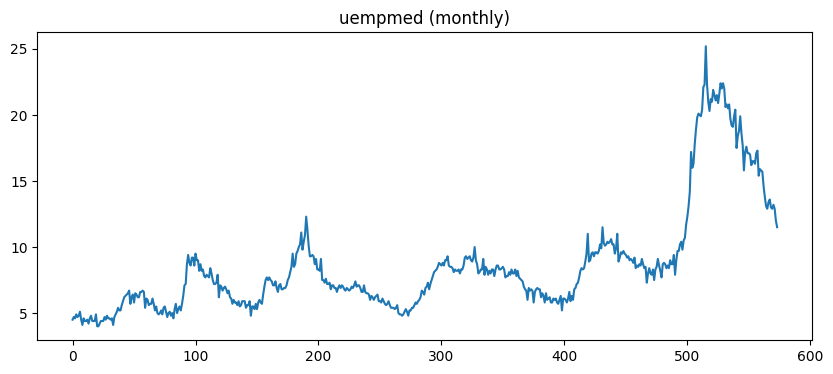

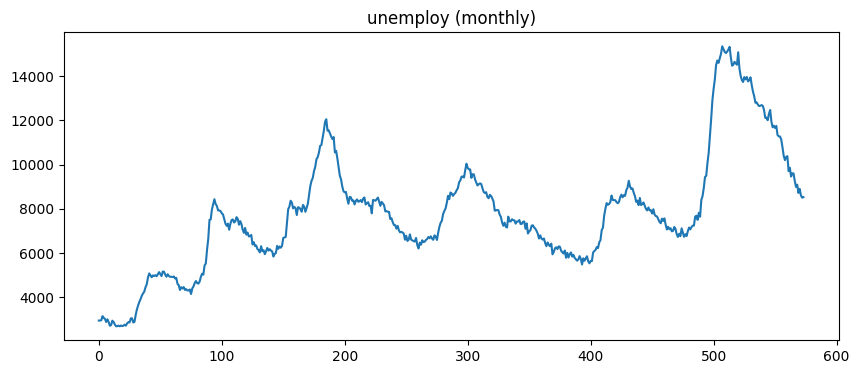

In [ ]:
# Line plots: Indicators by months.

for c in econ.columns[1:]:
  plt.figure(figsize=(10,4))
  plt.plot(econ[c])
  plt.title(c + " (monthly)")
  plt.show()

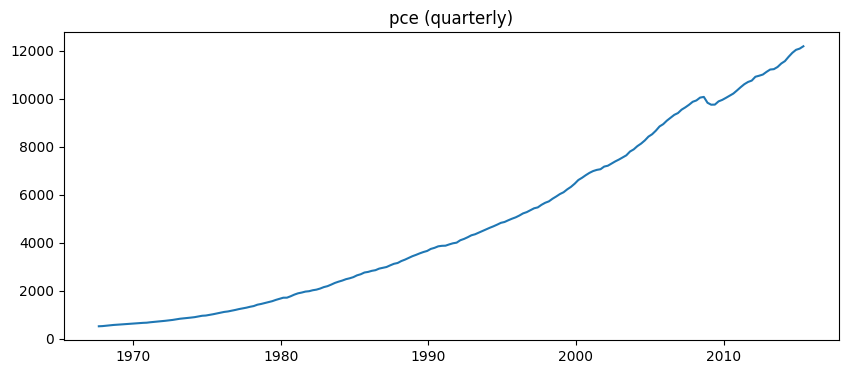

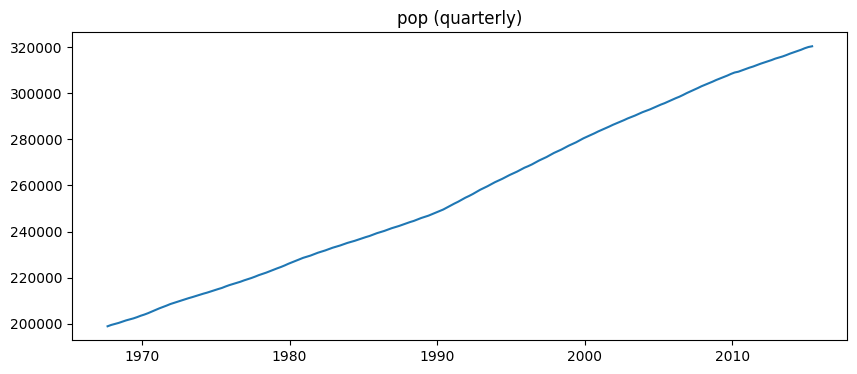

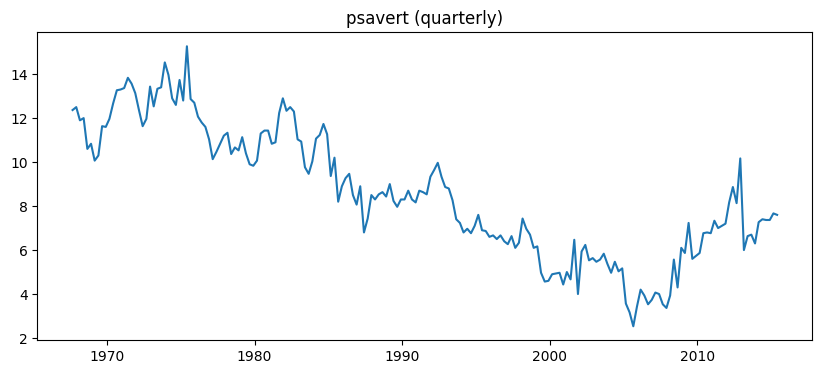

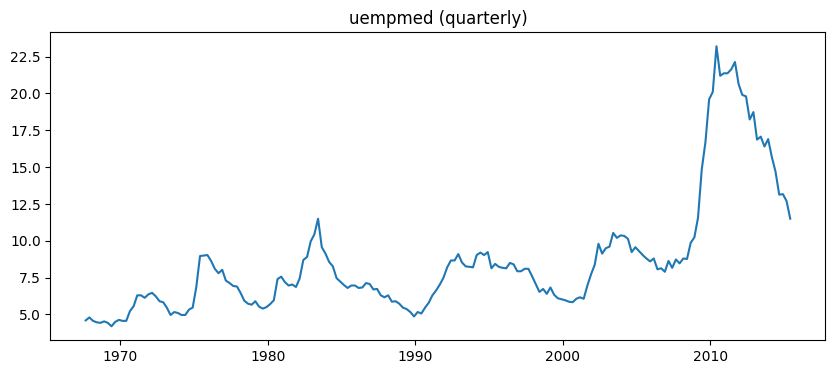

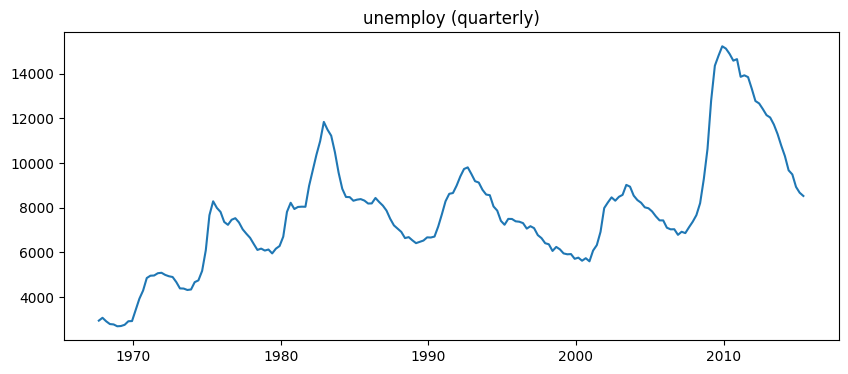

In [ ]:
# Line plots: Indicators by quarters
cp_econ = econ.copy()
cp_econ['date'] = cp_econ['date'].dt.to_period('Q').dt.strftime('%Y-%m')
cp_econ['date'] = pd.to_datetime(cp_econ['date'])
cp_econ = cp_econ.groupby('date').mean()

for c in cp_econ.columns:
  plt.figure(figsize=(10,4))
  plt.plot(cp_econ.index, cp_econ[c])
  plt.title(c + " (quarterly)")
  plt.show()

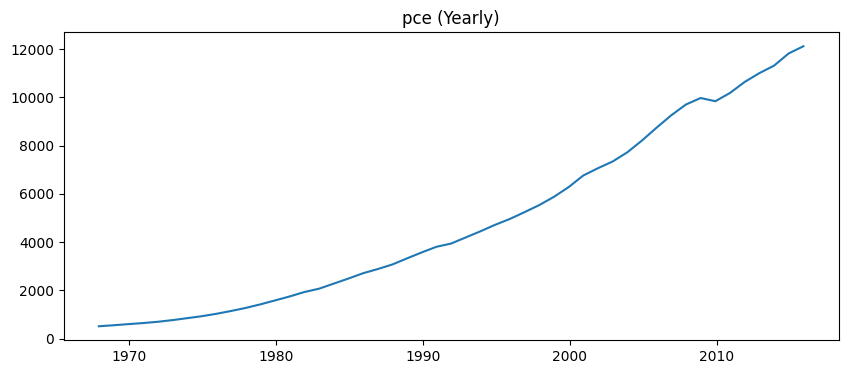

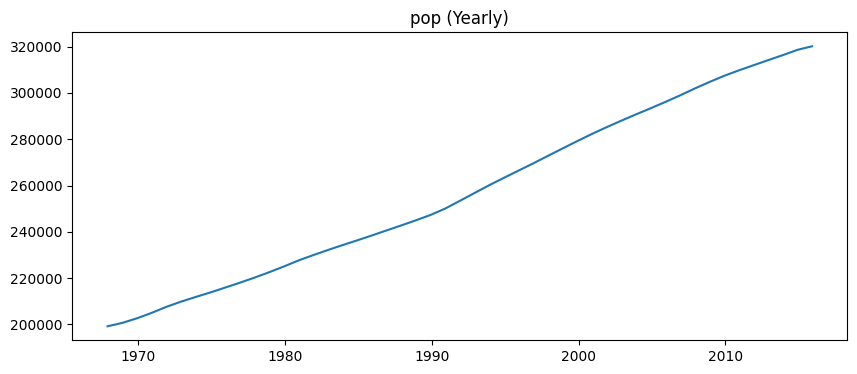

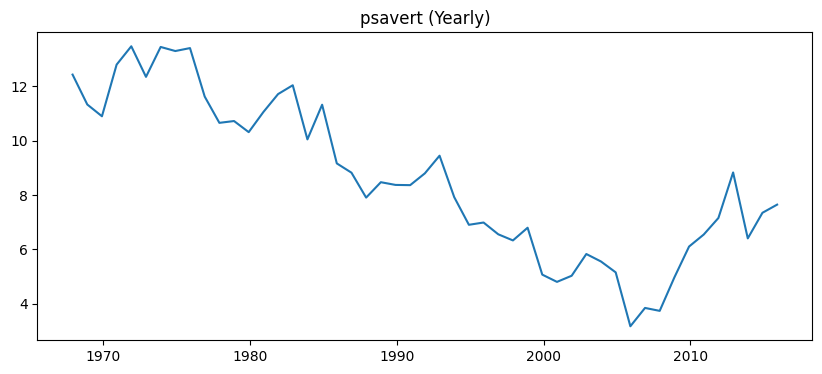

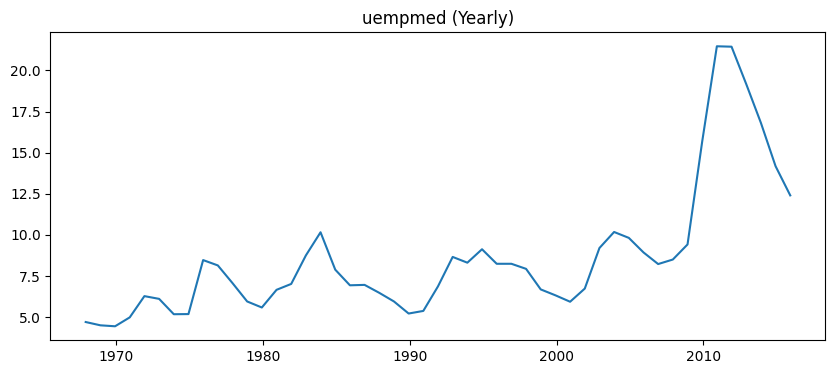

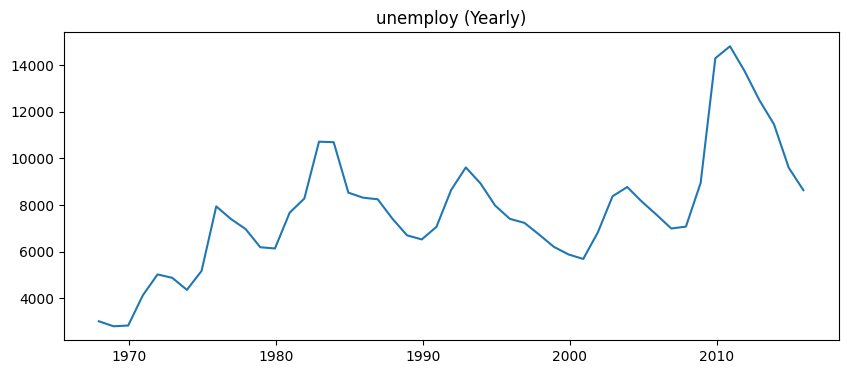

In [ ]:
# Line plots: Indicators by years
cp_econ = econ.copy()
cp_econ['date'] = cp_econ['date'].dt.to_period('Y').dt.strftime('%Y-%m')
cp_econ['date'] = pd.to_datetime(cp_econ['date'])
cp_econ = cp_econ.groupby('date').mean()

for c in cp_econ.columns:
  plt.figure(figsize=(10,4))
  plt.plot(cp_econ.index, cp_econ[c])
  plt.title(c + " (Yearly)")
  plt.show()

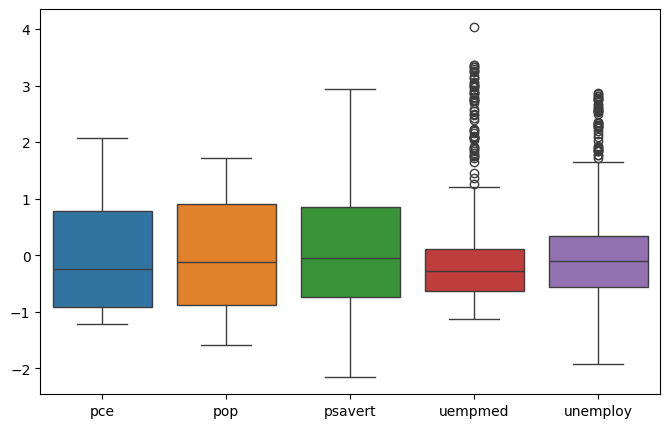

In [ ]:
# Box plot
cp_econ = econ[["pce", "pop", "psavert", "uempmed", "unemploy"]].copy()
for c in cp_econ.columns:
  cp_econ[c] = StandardScaler().fit_transform(cp_econ[c].values.reshape(-1,1))

plt.figure(figsize=(8,5))
sns.boxplot(cp_econ)
plt.show()

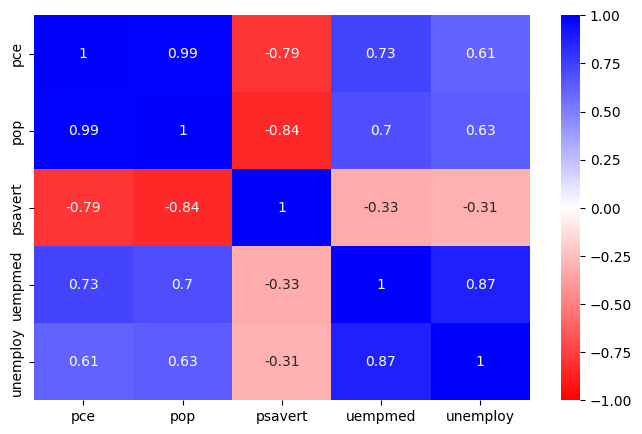

In [ ]:
# Heatmap: Correlation
cp_econ = econ.copy()
plt.figure(figsize=(8,5))
sns.heatmap(cp_econ[cp_econ.columns[1:]].corr(), cmap="bwr_r", vmin=-1, vmax=1, center=0, annot=True)
plt.show()


## **Autocorrelation Function (ACF) and Particial Autocorrelation Function (PACF)**

### How to interpret ACF and PACF ?  
https://chatgpt.com/share/696d0834-02bc-800f-ad86-f1d57cadd2d5  
| events                         | ACF                    | PACF         |
| ---                            | ---                    |---           |
| slowly decay                   | trend & non-stationary | MA behaviour |
| interval of local extrema      | seasonality            | Seasonal AR  |
| a peak, after that is a cutoff | MA(q)                  | AR(p)        |
| spikes in confidence interval  | noises                 | noises       |

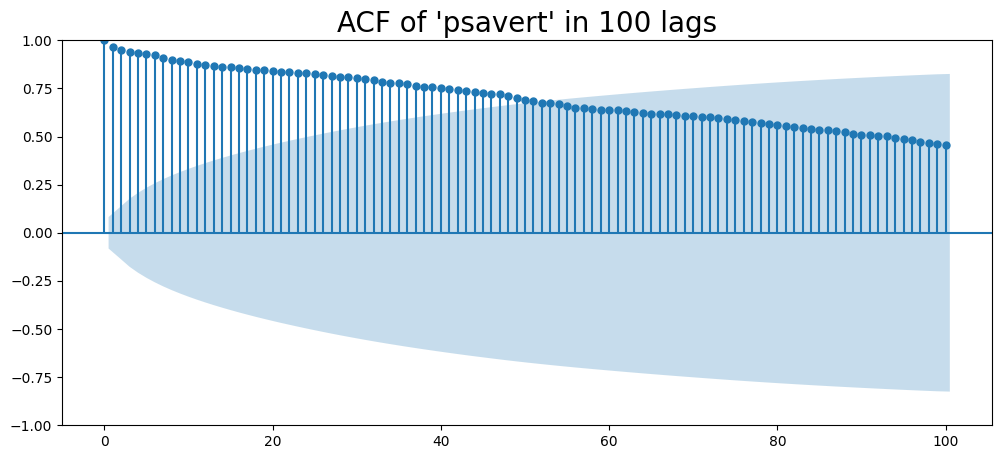

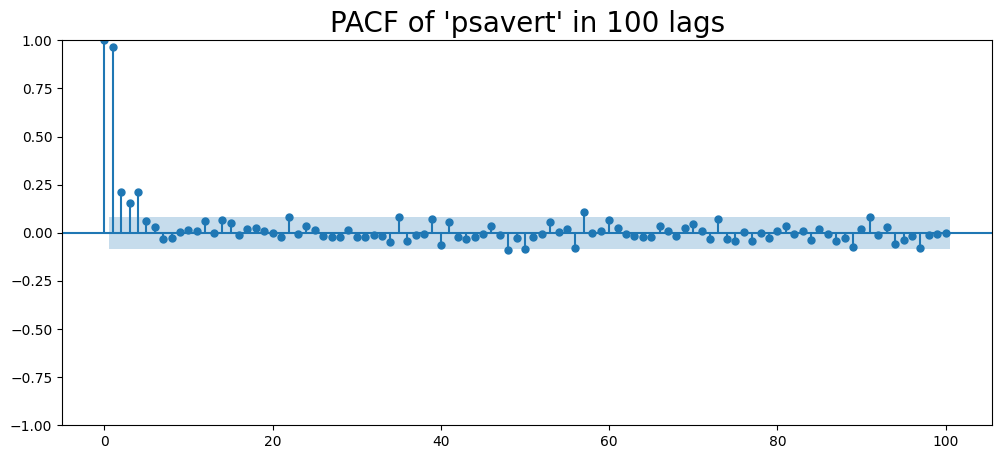

In [ ]:
# ACF & PACF of 'psavert'
plt.figure(figsize=(12,5))
plot_acf(econ['psavert'], ax=plt.gca(), lags=100)
plt.title("ACF of 'psavert' in 100 lags", fontdict={'size':20})
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(econ['psavert'], ax=plt.gca(), lags=100)
plt.title("PACF of 'psavert' in 100 lags", fontdict={'size':20})
plt.show()

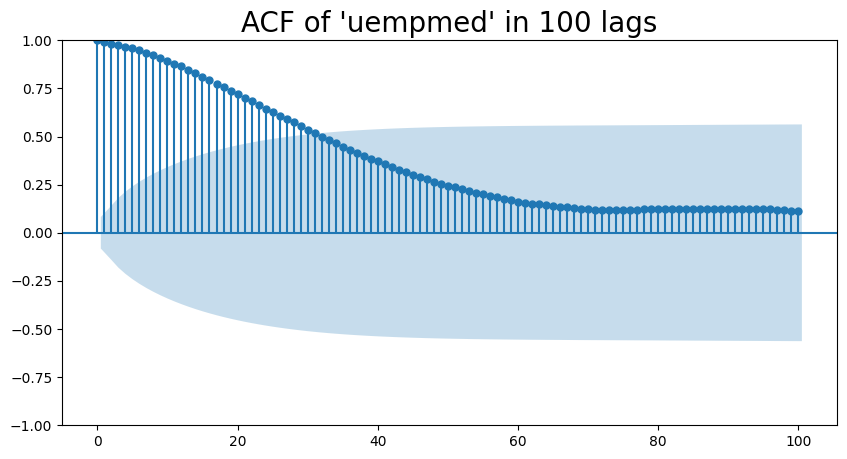

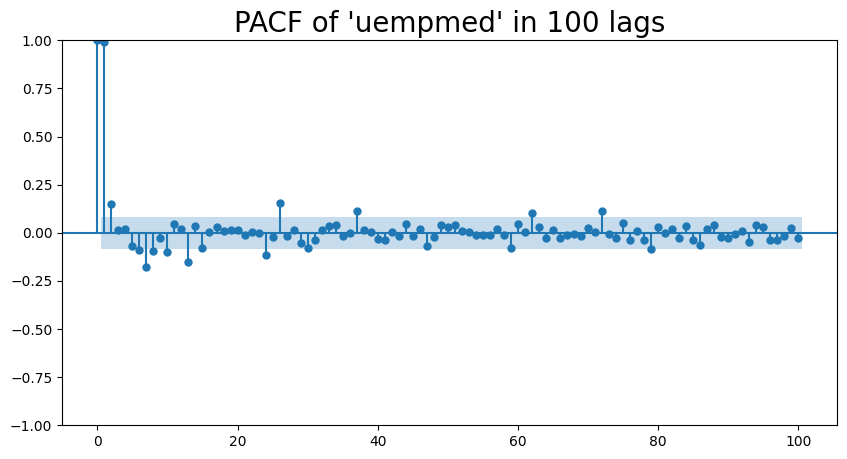

In [ ]:
# ACF & PACF of 'uempmed'
plt.figure(figsize=(10,5))
plot_acf(econ['uempmed'], ax=plt.gca(), lags=100)
plt.title("ACF of 'uempmed' in 100 lags", fontdict={'size':20})
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(econ['uempmed'], ax=plt.gca(), lags=100)
plt.title("PACF of 'uempmed' in 100 lags", fontdict={'size':20})
plt.show()

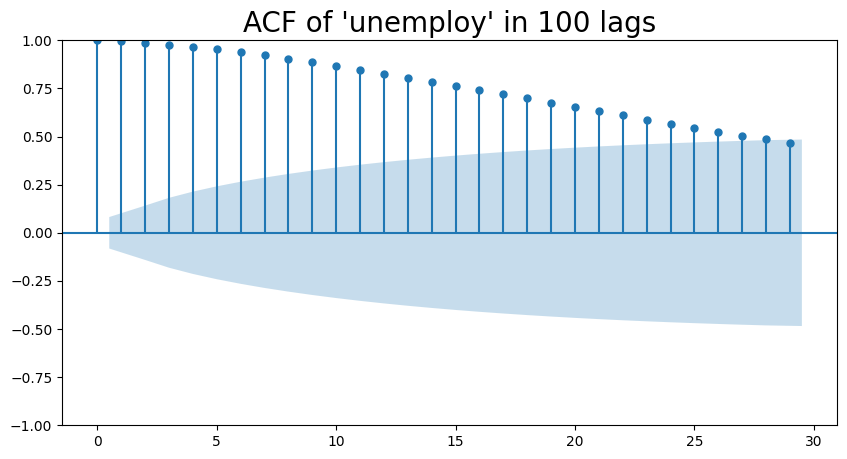

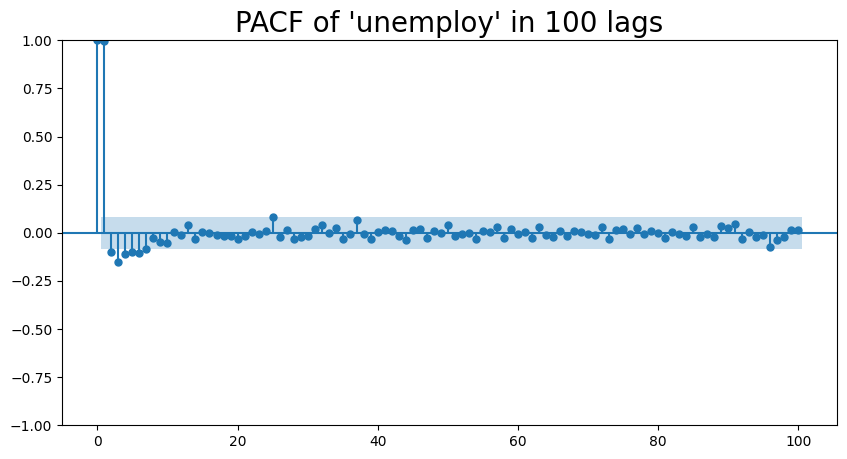

In [ ]:
# ACF & PACF of 'unemploy'
plt.figure(figsize=(10,5))
plot_acf(econ['unemploy'], ax=plt.gca(), lags=29)
plt.title("ACF of 'unemploy' in 100 lags", fontdict={'size':20})
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(econ['unemploy'], ax=plt.gca(), lags=100)
plt.title("PACF of 'unemploy' in 100 lags", fontdict={'size':20})
plt.show()

## **TIME SERIES DECOMPOSITION**

tutorial in a nutshell:  
https://www.youtube.com/shorts/obegcD_VkLk  
\
Why values of seasonality oscillate around 0 ?  
https://chatgpt.com/c/696fa538-41dc-832d-a877-aa26fb75eb21  
"*The seasonal effect represents **deviations from the trend**, not absolute values. Positive values mean “above the trend”, negative values mean “below the trend. That naturally makes it oscillate around 0.*"  

In [ ]:
# set index to datetime
dt_econ = econ.set_index('date')

# As 'pop' and 'pce' have clear upward trends without any fluctuations, no need to apply decomposition on these columns.

econ_decompose = {'psavert':{}, 'uempmed':{}, 'unemploy':{}}
# Apply decomposition on other columns
for c in econ_decompose.keys():
  decomp = seasonal_decompose(dt_econ[c], 'additive')
  econ_decompose[c]['overall'] = decomp
  econ_decompose[c]['trend'] = decomp.trend
  econ_decompose[c]['seasonality'] = decomp.seasonal
  econ_decompose[c]['noise'] = decomp.resid

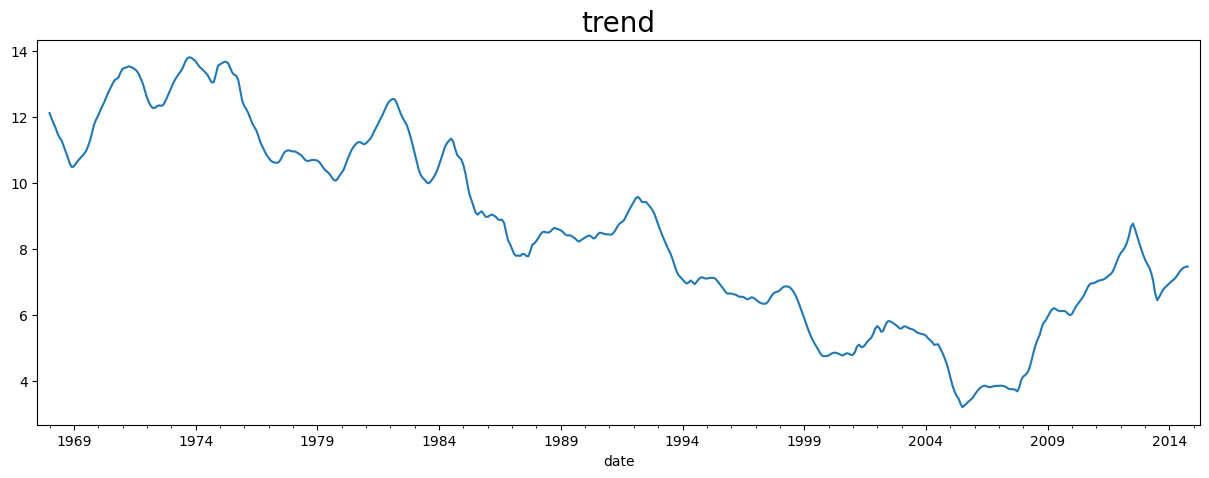

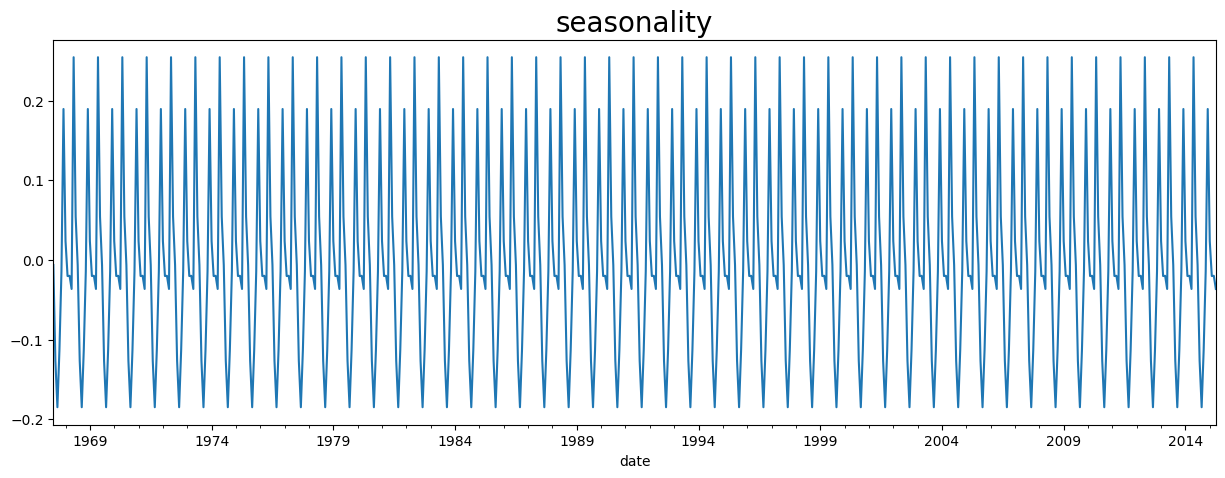

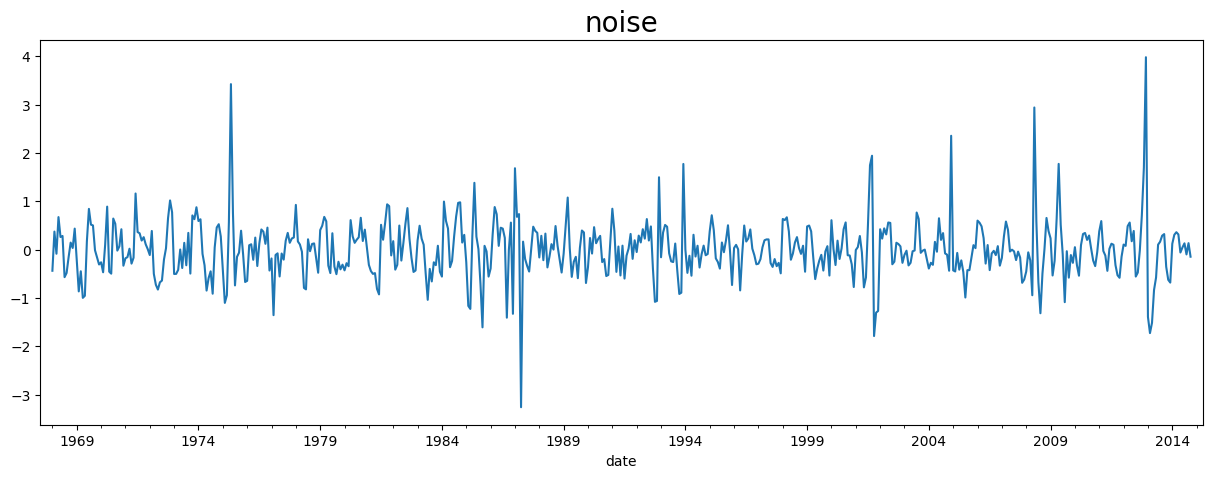

In [ ]:
# Seasonal decomposition of 'psavert'

for comp in econ_decompose['psavert'].keys():
  if comp == 'overall': continue
  plt.figure(figsize=(15,5))
  econ_decompose['psavert'][comp].plot()
  plt.title(comp, fontdict={'size':20})
  plt.show()

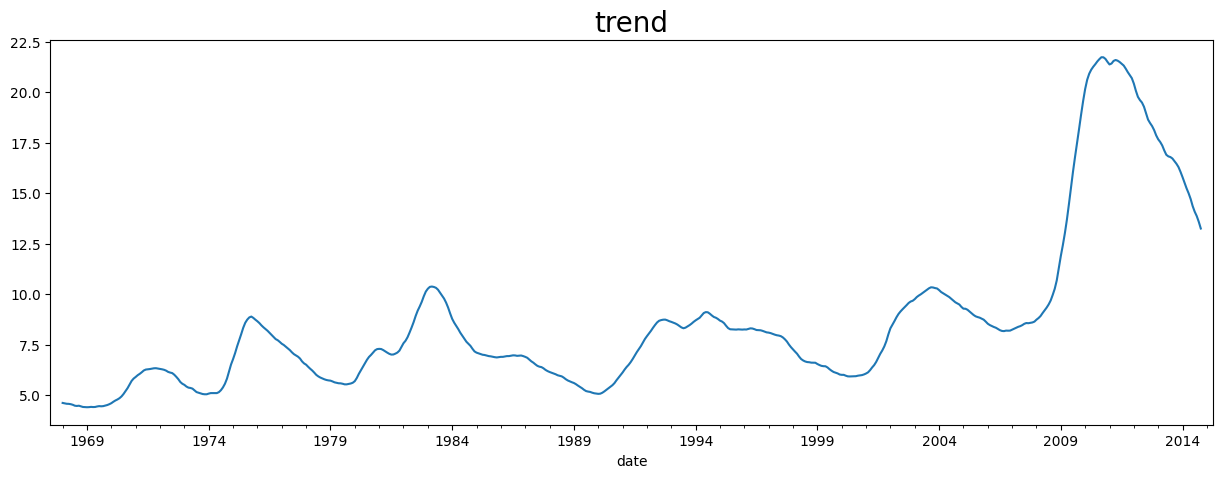

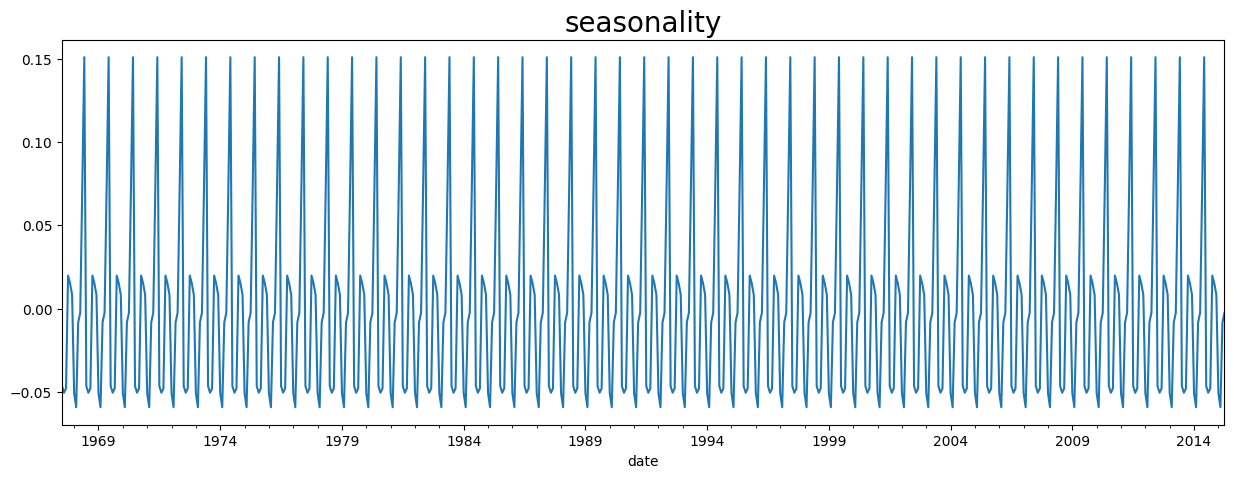

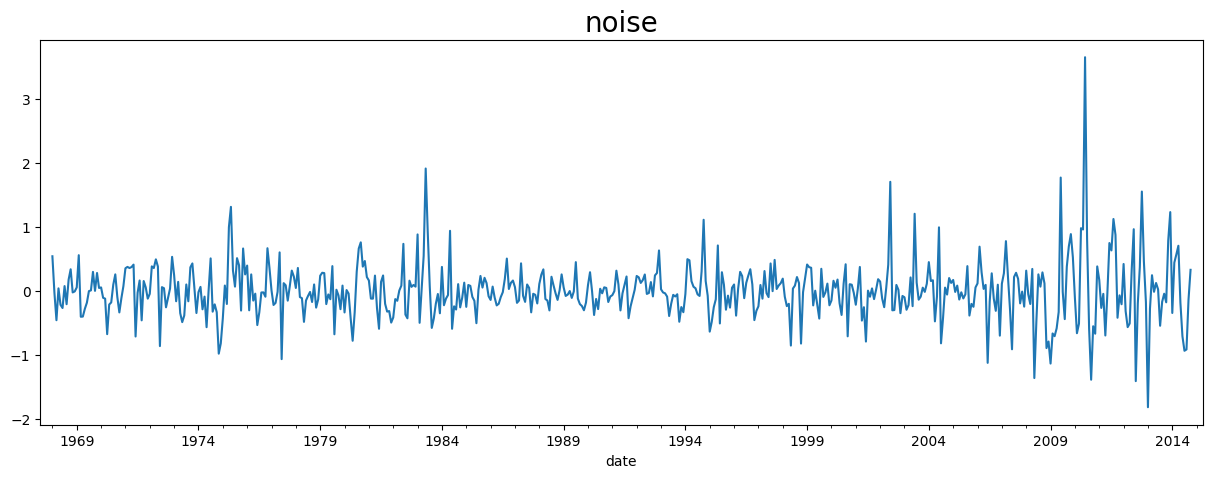

In [ ]:
# Seasonal decomposition of 'uempmed'

for comp in econ_decompose['uempmed'].keys():
  if comp == 'overall': continue
  plt.figure(figsize=(15,5))
  econ_decompose['uempmed'][comp].plot()
  plt.title(comp, fontdict={'size':20})
  plt.show()

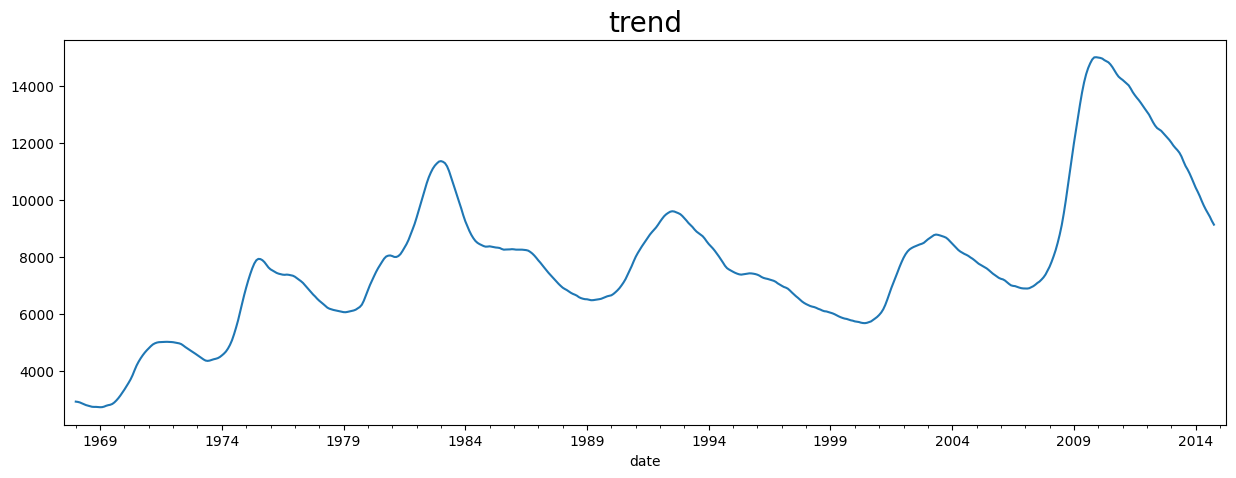

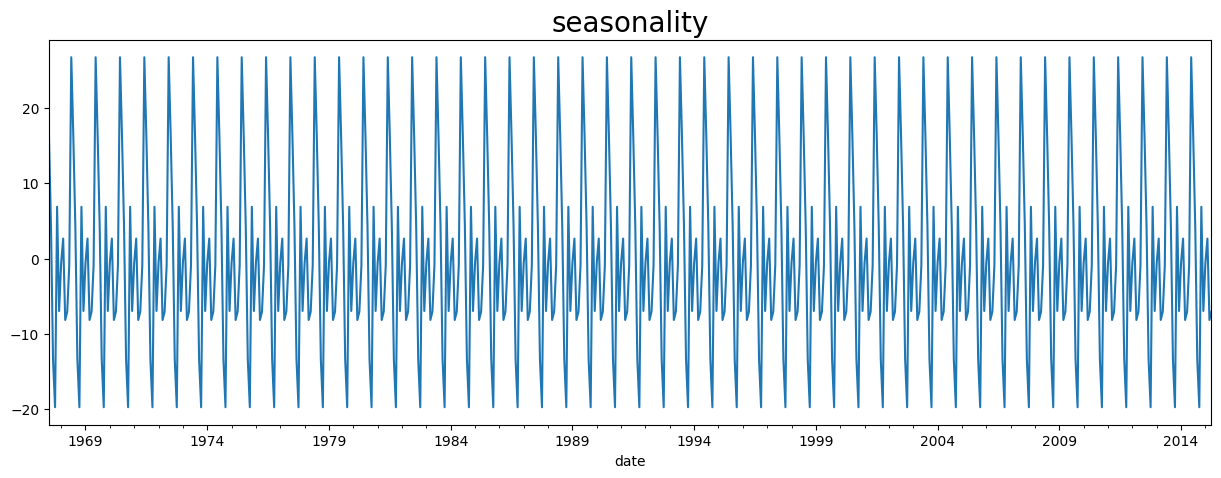

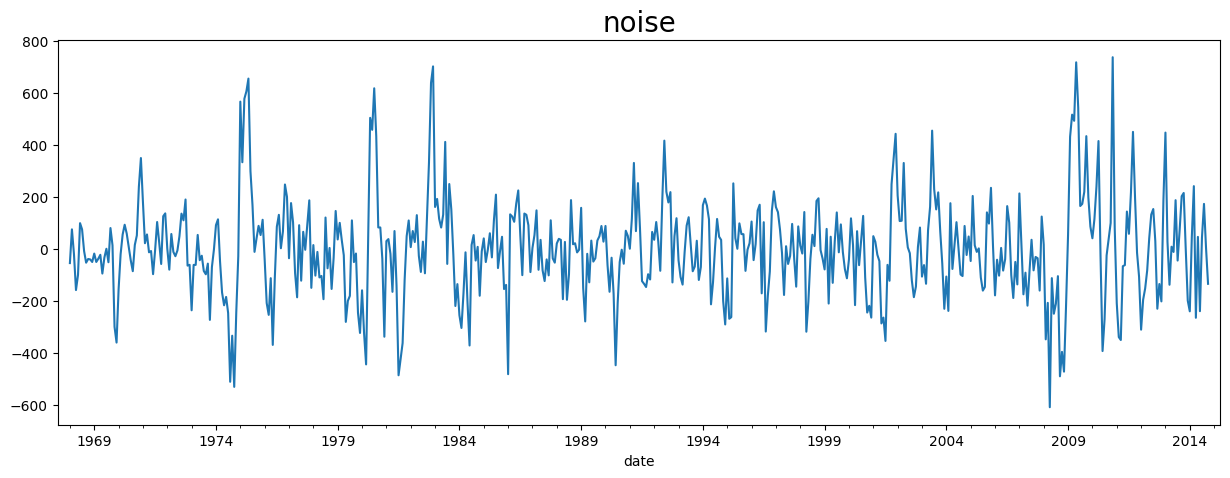

In [ ]:
# Seasonal decomposition of 'unemploy'

for comp in econ_decompose['unemploy'].keys():
  if comp == 'overall': continue
  plt.figure(figsize=(15,5))
  econ_decompose['unemploy'][comp].plot()
  plt.title(comp, fontdict={'size':20})
  plt.show()

## **INITIAL ADF TEST**

In [ ]:
def check_stationary(series):
  result = adfuller(series)

  print('ADF:\t\t', result[0])
  print('p-value:\t', result[1])
  print('Critical values:')
  for key, value in result[4].items():
    print(f"  - {key}: {value}")

  if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
    print("Stationary")
  else:
    print('Non-stationary')

for col in econ.columns[1:]:
  print(col)
  check_stationary(econ[col])
  print()

pce
ADF:		 4.901561672061071
p-value:	 1.0
Critical values:
  - 1%: -3.4418948967017475
  - 5%: -2.8666329082535222
  - 10%: -2.569482366838501
Non-stationary

pop
ADF:		 0.15700665715941217
p-value:	 0.9697444776693609
Critical values:
  - 1%: -3.44218748274498
  - 5%: -2.8667617276005006
  - 10%: -2.569551011281552
Non-stationary

psavert
ADF:		 -1.7741891336596567
p-value:	 0.39334925316658087
Critical values:
  - 1%: -3.4418948967017475
  - 5%: -2.8666329082535222
  - 10%: -2.569482366838501
Non-stationary

uempmed
ADF:		 -2.6230517017961525
p-value:	 0.08832592344782741
Critical values:
  - 1%: -3.442102384299813
  - 5%: -2.8667242618524233
  - 10%: -2.569531046591633
Non-stationary

unemploy
ADF:		 -3.0585256591039593
p-value:	 0.02977864721083319
Critical values:
  - 1%: -3.441935806025943
  - 5%: -2.8666509204896093
  - 10%: -2.5694919649816947
Stationary



In [ ]:
from statsmodels.tsa.stattools import kpss
def check_kpss(y):
  result2 = kpss(y)
  print("\n\033[38;5;67m----===== KPSS Test =====----\033[0m")
  print("KPSS:\t", result2[0])
  print("p-value:", result2[1])
  print("Critical values:")
  for key, value in result2[3].items():
      print(f"  - {key}: {value}")

  if (result2[1] < 0.05) | (result2[3]["5%"] < result2[0]):
      print("\033[38;5;10mNon-stationary\033[0m")
  else:
      print("\033[38;5;10mStationary\033[0m")

for col in econ:
  print(col)
  check_kpss(econ[col])
  print()

## unemploy is stationary in KDF, but not in KPSS
## Maybe we should treat it as non-stationary

date

----===== KPSS Test =====----
KPSS:	 3.479149216254215
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non-stationary

pce

----===== KPSS Test =====----
KPSS:	 3.3764889265977094
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non-stationary

pop

----===== KPSS Test =====----
KPSS:	 3.481397547149257
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non-stationary

psavert

----===== KPSS Test =====----
KPSS:	 2.8686567705171298
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non-stationary

uempmed

----===== KPSS Test =====----
KPSS:	 1.697508917938251
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non-stationary

unemploy

----===== KPSS Test =====----
KPSS:	 1.4146648394276975
p-value: 0.01
Critical values:
  - 10%: 0.347
  - 5%: 0.463
  - 2.5%: 0.574
  - 1%: 0.739
Non

## **TRANSFORMATIONS AND RETESTING STATIONARY**

In ARIMA(p, d, q), parameter 'd' is times of differencing to achieve stationarity

ADF:		 -4.062335297681075
p-value:	 0.0011170725879928272
Critical values:
  - 1%: -3.4420185006698127
  - 5%: -2.8666873299250253
  - 10%: -2.5695113665058726
Stationary


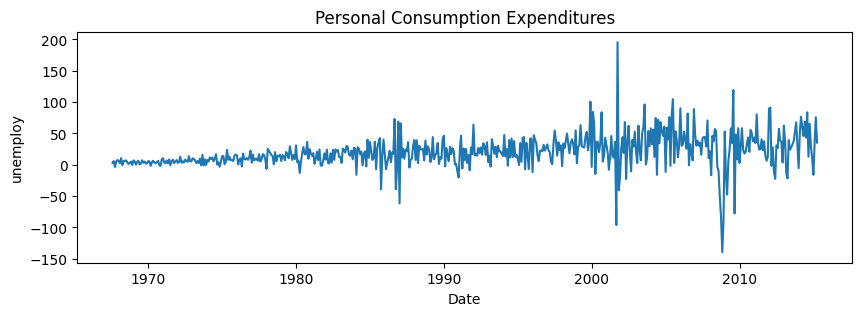

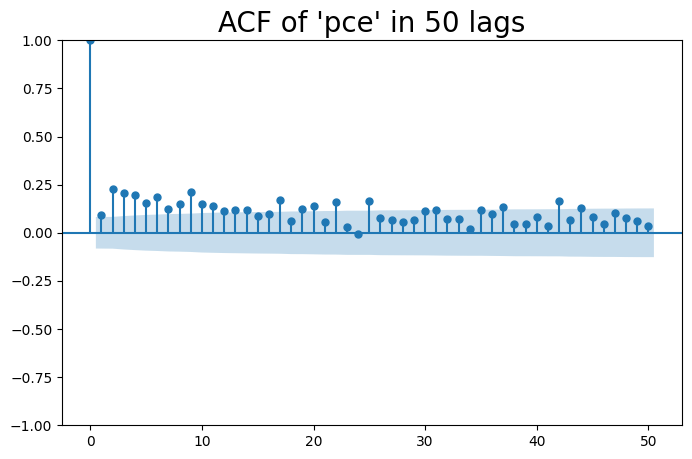

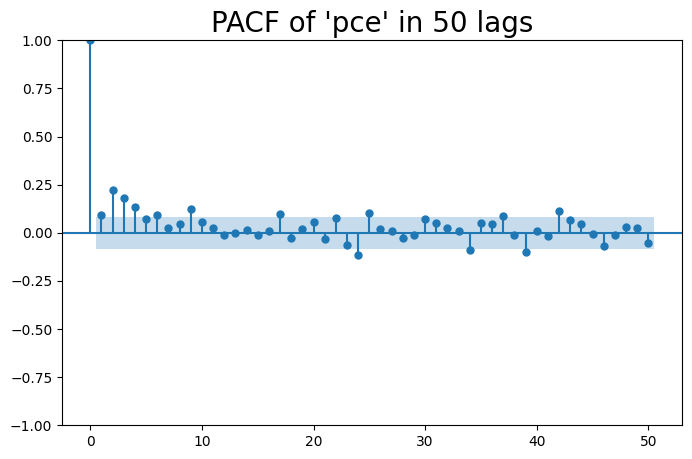

In [ ]:
# I just diff it until it is stationary
col1 = econ['pce'].diff()
## note: np.log() removed, p-value changed, only diff x1 instead of x2 to be stationary.
## acf & pacf are also changed.
## log trans ruins the process, does not help stationalizing.

check_stationary(col1.dropna())

plt.figure(figsize=(10,3))
plt.plot(econ['date'], col1)
plt.title('Personal Consumption Expenditures')
plt.xlabel('Date')
plt.ylabel(col)
plt.show()

# plt.figure(figsize=(10,5))
# plot_acf(col1.dropna(), lags=50)
# plt.title("ACF of 'pce' in 50 lags", fontdict={'size':20})
# plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_acf(col1.dropna(), lags=50, ax=ax)
plt.title("ACF of 'pce' in 50 lags", fontsize=20)
plt.show()

# plt.figure(figsize=(8,5))
# plot_pacf(col1.dropna(), lags=50)
# plt.title("PACF of 'pce' in 50 lags", fontdict={'size':20})
# plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_pacf(col1.dropna(), lags=50, ax=ax)
plt.title("PACF of 'pce' in 50 lags", fontsize=20)
plt.show()

ADF:		 -5.344928246196709
p-value:	 4.416478167820316e-06
Critical values:
  - 1%: -3.4421660928041633
  - 5%: -2.8667523104859627
  - 10%: -2.56954599309042
Stationary


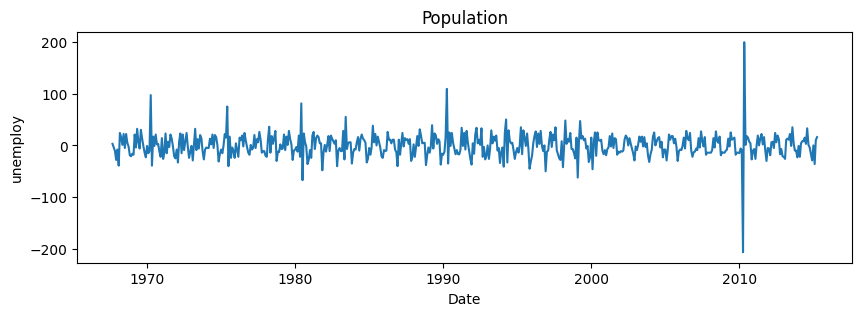

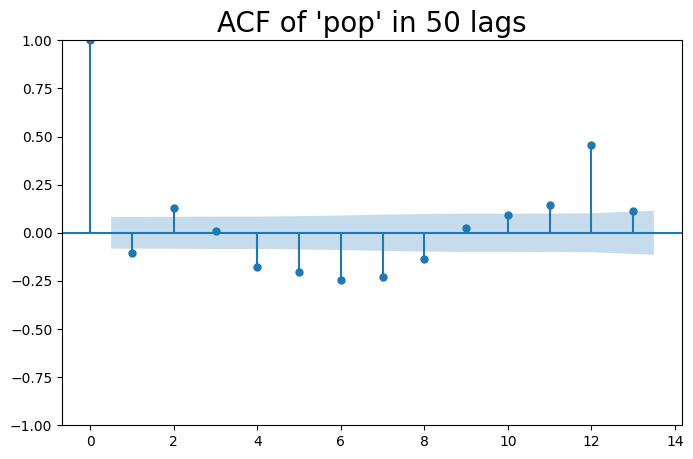

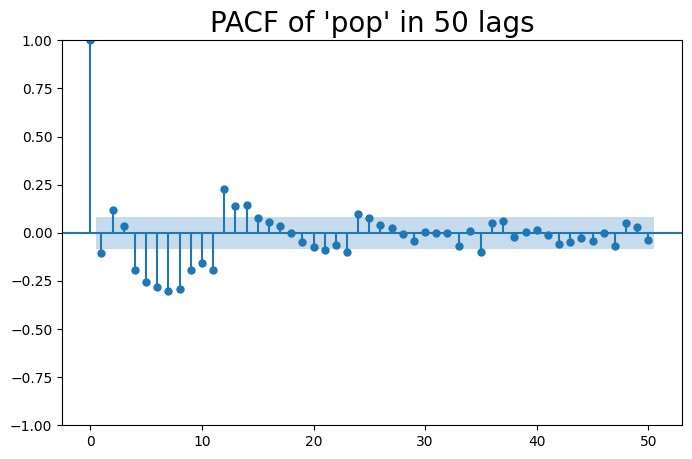

In [ ]:
# Same as before
col2 = econ['pop'].diff().diff()
## np.log() is removed but still need x2 diff.

check_stationary(col2.dropna())

plt.figure(figsize=(10,3))
plt.plot(econ['date'], col2)
plt.title('Population')
plt.xlabel('Date')
plt.ylabel(col)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_acf(col2.dropna(), lags=13, ax=ax)
plt.title("ACF of 'pop' in 50 lags", fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_pacf(col2.dropna(), lags=50, ax=ax)
plt.title("PACF of 'pop' in 50 lags", fontsize=20)
plt.show()

ADF:		 -17.02257436660074
p-value:	 8.436173549113168e-30
Critical values:
  - 1%: -3.4418948967017475
  - 5%: -2.8666329082535222
  - 10%: -2.569482366838501
Stationary


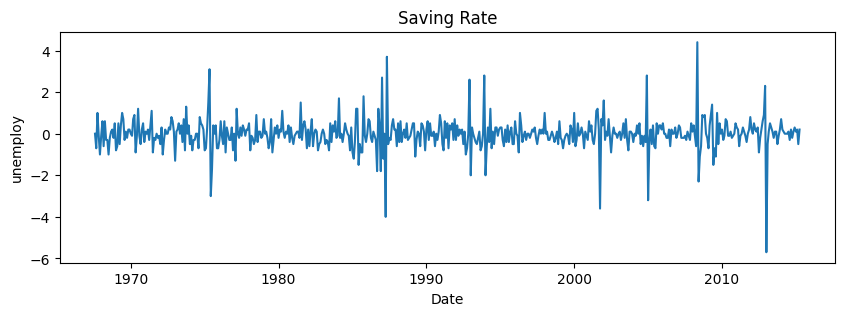

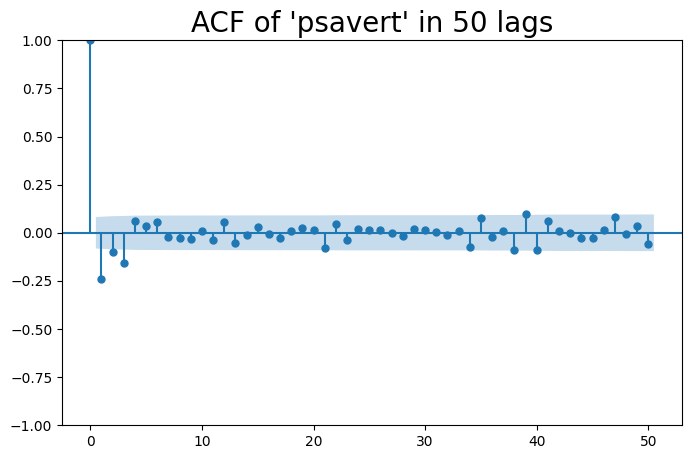

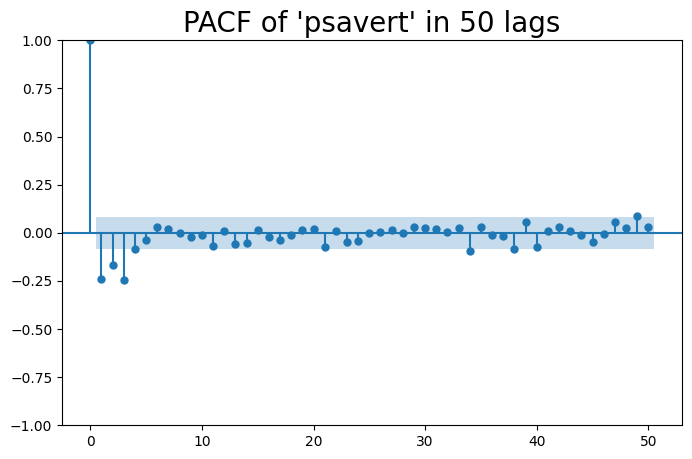

In [ ]:
# Small enough, no log
col3 = econ['psavert'].diff()

check_stationary(col3.dropna())

plt.figure(figsize=(10,3))
plt.plot(econ['date'], col3)
plt.title('Saving Rate')
plt.xlabel('Date')
plt.ylabel(col)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_acf(col3.dropna(), lags=50, ax=ax)
plt.title("ACF of 'psavert' in 50 lags", fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_pacf(col3.dropna(), lags=50, ax=ax)
plt.title("PACF of 'psavert' in 50 lags", fontsize=20)
plt.show()

ADF:		 -4.322773763004428
p-value:	 0.0004055588807146166
Critical values:
  - 1%: -3.442102384299813
  - 5%: -2.8667242618524233
  - 10%: -2.569531046591633
Stationary


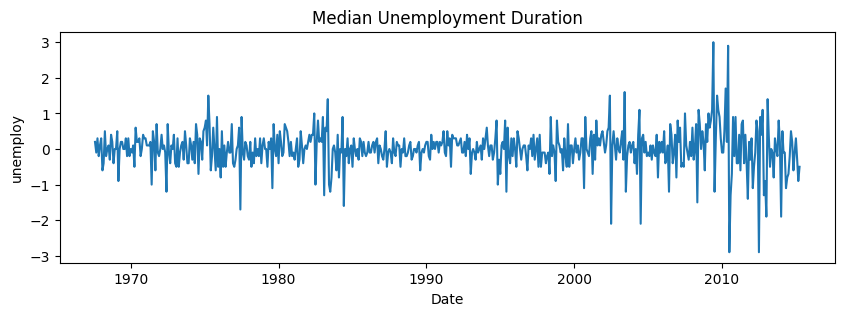

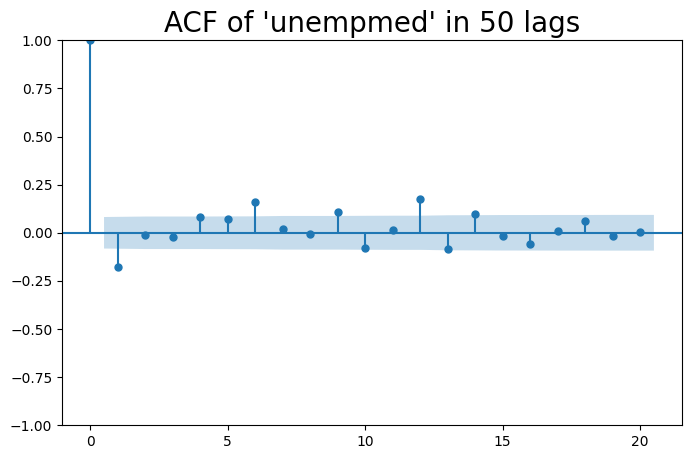

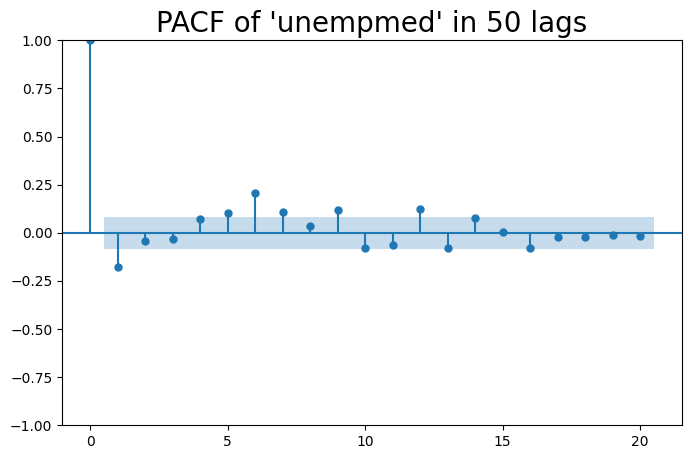

In [ ]:
col4 = econ['uempmed'].diff()

check_stationary(col4.dropna())

plt.figure(figsize=(10,3))
plt.plot(econ['date'], col4)
plt.title('Median Unemployment Duration')
plt.xlabel('Date')
plt.ylabel(col)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_acf(col4.dropna(), lags=20, ax=ax)
plt.title("ACF of 'unempmed' in 50 lags", fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_pacf(col4.dropna(), lags=20, ax=ax)
plt.title("PACF of 'unempmed' in 50 lags", fontsize=20)
plt.show()

ADF:		 -17.52498298514211
p-value:	 4.26607890060639e-30
Critical values:
  - 1%: -3.441935806025943
  - 5%: -2.8666509204896093
  - 10%: -2.5694919649816947
Stationary


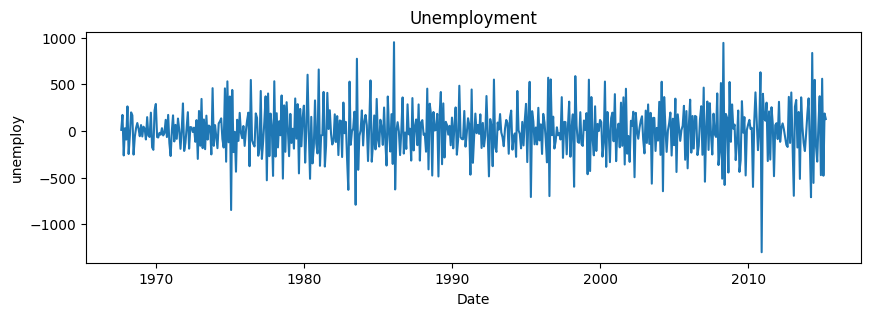

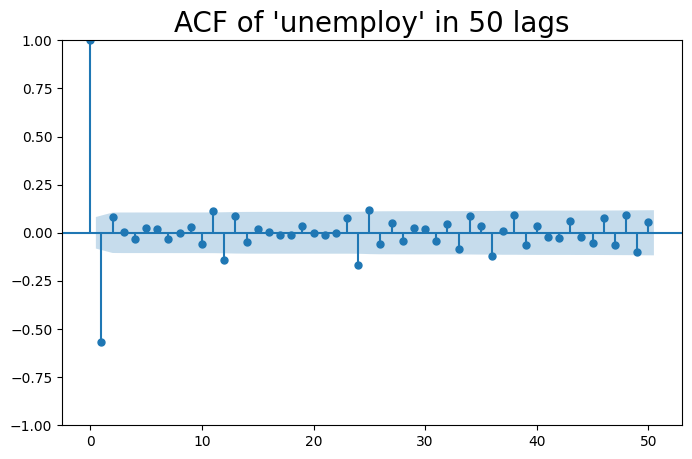

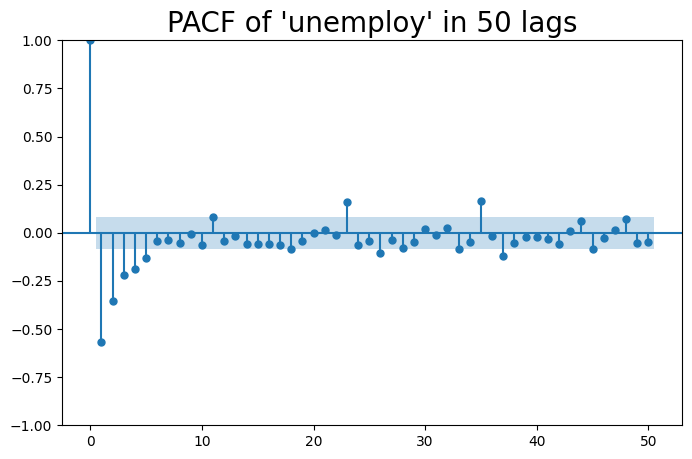

In [ ]:
col4 = econ['unemploy'].diff().diff()

check_stationary(col4.dropna())

plt.figure(figsize=(10,3))
plt.plot(econ['date'], col4)
plt.title('Unemployment')
plt.xlabel('Date')
plt.ylabel(col)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_acf(col4.dropna(), lags=50, ax=ax)
plt.title("ACF of 'unemploy' in 50 lags", fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
plot_pacf(col4.dropna(), lags=50, ax=ax)
plt.title("PACF of 'unemploy' in 50 lags", fontsize=20)
plt.show()

## **ARIMA MODEL SELECTION**
ACF determines q  
PACF determines p

In [ ]:
# Function for ranking orders for ARIMA model
# By default, we prioritize on AIC for predictive performance
def rankingOrdersARIMA(ts, candidates, criterion='aic'):
  aics = []
  bics = []

  for p, d, q in candidates:
    mdl = ARIMA(ts, order=(p, d, q)).fit(method_kwargs={'maxiter':1000})
    aics.append(mdl.aic)
    bics.append(mdl.bic)

  rankings = pd.DataFrame({
      'Orders': candidates,
      'AIC': aics,
      'BIC': bics
  })

  rankings = rankings.set_index('Orders')
  rankings = rankings.sort_values(by=criterion.upper(), ascending=True)

  return rankings

In [ ]:
econ_dt = econ.copy()
try:
  econ_dt.index = pd.DatetimeIndex(econ_dt['date'].values, freq=econ_dt.index.inferred_freq)
  econ_dt = econ_dt.drop(columns='date')
except:
  pass

display(econ_dt.head())

# collecting candidates
pce_pdq = [(1,1,1), (0,1,0)]
pop_pdq = [(1,2,1), (0,2,0)]
psavert_pdq = [(1,1,1), (0,1,0), (1,2,1), (0,2,0), (0,2,1), (1,2,0)]
uempmed_pdq = [(1,1,1), (0,1,0), (1,1,0), (0,1,1), (0,2,0), (1,2,1), (1,2,0), (0,2,1), (3,1,3)]
unemploy_pdq = [(1,0,1), (1,0,0), (1,1,1), (0,1,0), (0,2,0), (1,2,1), (1,2,0), (0,2,1), (1,1,0), (0,1,1)]

,date,pce,pop,psavert,uempmed,unemploy
0,1967-07-01,506.7,198712,12.6,4.5,2944
1,1967-08-01,509.8,198911,12.6,4.7,2945
2,1967-09-01,515.6,199113,11.9,4.6,2958
3,1967-10-01,512.2,199311,12.9,4.9,3143
4,1967-11-01,517.4,199498,12.8,4.7,3066


In [ ]:
# psavert (Personal Saving Rate)
display(rankingOrdersARIMA(econ_dt['psavert'], psavert_pdq, criterion='bic'))

,AIC,BIC
Orders,,
"(1, 1, 1)",1219.105467,1232.158124
"(1, 2, 1)",1268.347506,1281.394923
"(0, 1, 0)",1292.536469,1296.887355
"(0, 2, 1)",1299.556157,1308.254435
"(1, 2, 0)",1601.324944,1610.023222
"(0, 2, 0)",1810.308462,1814.657601


In [ ]:
# uempmed (Median Unemployment Duration)
display(rankingOrdersARIMA(econ_dt['uempmed'], uempmed_pdq, criterion='bic'))

,AIC,BIC
Orders,,
"(3, 1, 3)",925.413553,955.869753
"(0, 1, 1)",952.982958,961.684730
"(1, 1, 0)",954.099691,962.801462
"(1, 1, 1)",954.959869,968.012526
"(1, 2, 1)",959.854553,972.901970
"(0, 1, 0)",970.563948,974.914834
"(0, 2, 1)",977.954644,986.652922
"(1, 2, 0)",1235.177021,1243.875299
"(0, 2, 0)",1459.710662,1464.059801


In [ ]:
# unemploy (Unemployment)
display(rankingOrdersARIMA(econ_dt['unemploy'], unemploy_pdq, criterion='bic'))

,AIC,BIC
Orders,,
"(1, 2, 1)",7700.258709,7713.306126
"(0, 2, 1)",7708.326835,7717.025113
"(1, 1, 1)",7704.238204,7717.290861
"(1, 1, 0)",7769.979843,7778.681614
"(0, 1, 1)",7776.758293,7785.460064
"(0, 1, 0)",7787.636926,7791.987812
"(1, 0, 1)",7798.669007,7816.079525
"(1, 0, 0)",7809.902130,7822.960018
"(1, 2, 0)",7836.364504,7845.062782


## **ARIMA MODEL BUILDING (FIT FULL SERIES)**

                               SARIMAX Results                                
Dep. Variable:                psavert   No. Observations:                  574
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -606.553
Date:                Thu, 09 Apr 2026   AIC                           1219.105
Time:                        06:36:03   BIC                           1232.158
Sample:                             0   HQIC                          1224.197
                                - 574                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3703      0.062      5.955      0.000       0.248       0.492
ma.L1         -0.7236      0.054    -13.395      0.000      -0.830      -0.618
sigma2         0.4861      0.013     36.398      0.0

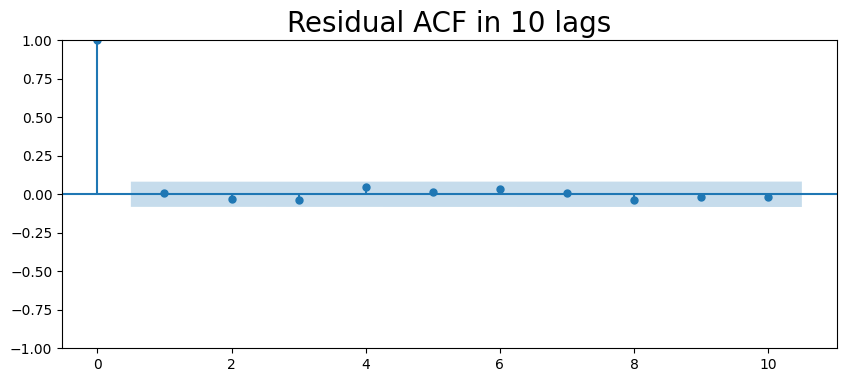

In [ ]:
# psavert (Personal Saving Rate)
psavert_mdl = ARIMA(econ_dt['psavert'], order=(1,1,1))
psavert_mdl_ft = psavert_mdl.fit(method_kwargs={'maxiter':1000})
print(psavert_mdl_ft.summary())

print(np.mean(psavert_mdl_ft.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(psavert_mdl_ft.resid, lags=10, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

                               SARIMAX Results                                
Dep. Variable:                uempmed   No. Observations:                  574
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -455.707
Date:                Thu, 09 Apr 2026   AIC                            925.414
Time:                        06:36:07   BIC                            955.870
Sample:                             0   HQIC                           937.294
                                - 574                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3447      0.076      4.533      0.000       0.196       0.494
ar.L2          0.8927      0.034     26.430      0.000       0.827       0.959
ar.L3         -0.4387      0.061     -7.140      0.0

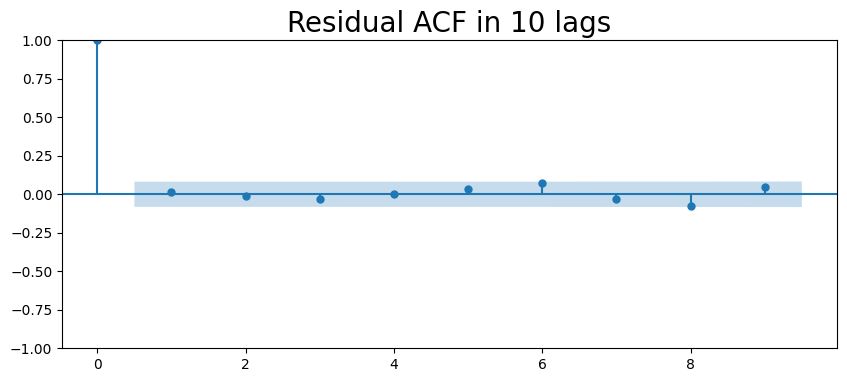

In [ ]:
# uempmed (Median Unemployment Rate)
uempmed_mdl = ARIMA(econ_dt['uempmed'], order=(3,1,3))
uempmed_mdl_ft = uempmed_mdl.fit(method_kwargs={'maxiter':1000})
print(uempmed_mdl_ft.summary())

print(np.mean(uempmed_mdl_ft.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(uempmed_mdl_ft.resid, lags=9, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

                               SARIMAX Results                                
Dep. Variable:               unemploy   No. Observations:                  574
Model:                 ARIMA(0, 2, 1)   Log Likelihood               -3852.163
Date:                Thu, 09 Apr 2026   AIC                           7708.327
Time:                        06:36:07   BIC                           7717.025
Sample:                             0   HQIC                          7711.720
                                - 574                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8223      0.021    -39.611      0.000      -0.863      -0.782
sigma2       4.13e+04   1935.736     21.336      0.000    3.75e+04    4.51e+04
Ljung-Box (L1) (Q):                   6.05   Jarque-

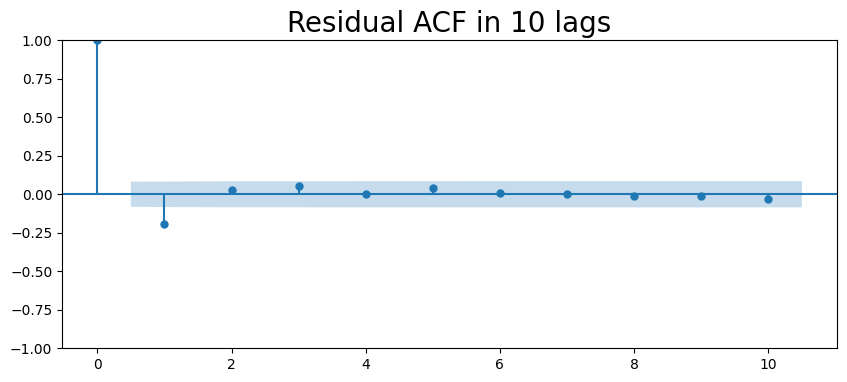

In [ ]:
# unemploy (Unemployment)
unemploy_mdl = ARIMA(econ_dt['unemploy'], order=(0,2,1))
unemploy_mdl_ft = unemploy_mdl.fit(method_kwargs={'maxiter':1000})
print(unemploy_mdl_ft.summary())

print(np.mean(unemploy_mdl_ft.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(unemploy_mdl_ft.resid, lags=10, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

## **ARIMA MODELS EVALUATION (MULTI-STEP VS. 1-STEP AHEAD FORECAST)**
- **Multi-step forecast**: normal forecast. The model is fitted only once, then forecast on multiple future steps.  
- **Rolling 1-step ahead forecast**: aka. real-time forecast. At each time a new value is forecasted and updated to the training dataset, then using that dataset to refit the model to forecast new value and continue the process until reaching the defined limit.

In [ ]:
# Split train test 85/15'
cp_econ = econ.copy().set_index('date')
train_size = int(econ.shape[0]*0.85)
econ_train, econ_test = cp_econ[:train_size], cp_econ[train_size:]
print(train_size)

# forecast steps
forecast_range = econ_test.shape[0]

487


In [ ]:
# 1-step ahead forecast function
def rolling_ahead_forecast(train, test, order:tuple):
  history = list(train.values)
  forecasts = []

  for t in range(len(test.values)):
    mdl = ARIMA(history, order=order)
    mdl_ft = mdl.fit(method_kwargs={'maxiter':1000})

    pred = mdl_ft.forecast(steps=1)
    forecasts.append(pred)

    history.pop(0)
    history.append(test.values[t])

  forecast_series = pd.Series(forecasts, index=test.index)

  mse = mean_squared_error(test.values, forecast_series.values)
  mae = mean_absolute_error(test.values, forecast_series.values)
  mape = mean_absolute_percentage_error(test.values, forecast_series.values)

  return forecast_series, mse, mae, mape

In [ ]:
# psavert (Personal Saving Rate)
psavert_realtime_forecast, psavert_mse, psavert_mae, psavert_mape = rolling_ahead_forecast(econ_train['psavert'], econ_test['psavert'], order=(1,1,1))

psavert_multistep_forecast = pd.Series(
    ARIMA(econ_train['psavert'], order=(1,1,1)).fit(method_kwargs={'maxiter':2000}).forecast(steps=len(econ_test['psavert'])),
    index = econ_test.index
)

Multi-step MSE: 12.28
Multi-step MAE: 3.27
Multi-step MAPE: 0.46

1-step MSE: 0.84
1-step MAE: 0.54
1-step MAPE: 0.08


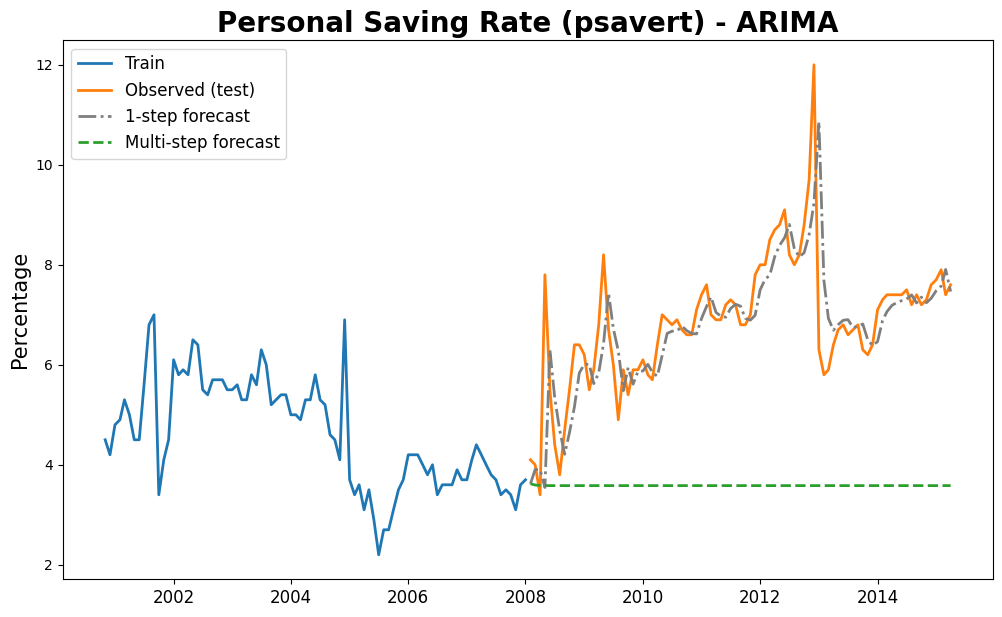

In [ ]:
print(f"Multi-step MSE: {mean_squared_error(econ_test['psavert'].values, psavert_multistep_forecast.values):.2f}")
print(f"Multi-step MAE: {mean_absolute_error(econ_test['psavert'].values, psavert_multistep_forecast.values):.2f}")
print(f"Multi-step MAPE: {mean_absolute_percentage_error(econ_test['psavert'].values, psavert_multistep_forecast.values):.2f}")
print()
print(f"1-step MSE: {psavert_mse:.2f}")
print(f"1-step MAE: {psavert_mae:.2f}")
print(f"1-step MAPE: {psavert_mape:.2f}")

plt.figure(figsize=(12,7))
plt.plot(econ_train['psavert'][400:], label="Train", lw=2)
plt.plot(econ_test['psavert'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(psavert_realtime_forecast, label="1-step forecast", c="tab:gray", ls="-.", lw=2)
plt.plot(psavert_multistep_forecast, label="Multi-step forecast", c="tab:green", ls="--", lw=2)
plt.ylabel("Percentage", fontsize=15)
plt.title("Personal Saving Rate (psavert) - ARIMA", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

In [ ]:
# uempmed (Personal Saving Rate)
uempmed_realtime_forecast, uempmed_mse, uempmed_mae, uempmed_mape = rolling_ahead_forecast(econ_train['uempmed'], econ_test['uempmed'], order=(3,1,3))

uempmed_multistep_forecast = pd.Series(
    ARIMA(econ_train['uempmed'], order=(3,1,3)).fit(method_kwargs={'maxiter':1000}).forecast(steps=len(econ_test['uempmed'])),
    index = econ_test.index
)

Multi-step MSE: 78.80
Multi-step MAE: 7.85
Multi-step MAPE: 0.43

1-step MSE: 0.94
1-step MAE: 0.70
1-step MAPE: 0.04


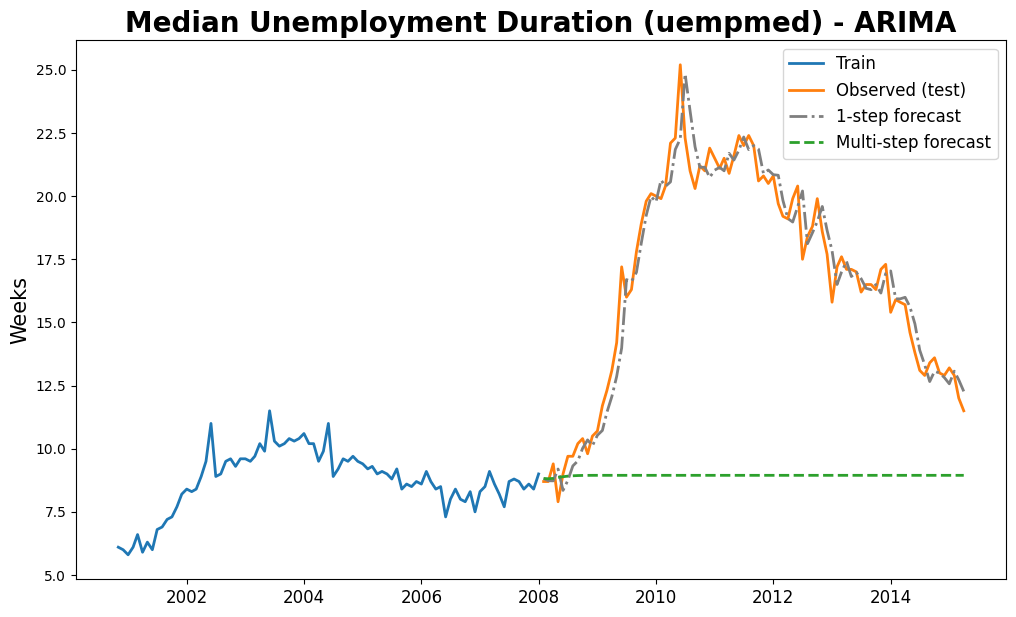

In [ ]:
print(f"Multi-step MSE: {mean_squared_error(econ_test['uempmed'].values, uempmed_multistep_forecast.values):.2f}")
print(f"Multi-step MAE: {mean_absolute_error(econ_test['uempmed'].values, uempmed_multistep_forecast.values):.2f}")
print(f"Multi-step MAPE: {mean_absolute_percentage_error(econ_test['uempmed'].values, uempmed_multistep_forecast.values):.2f}")
print()
print(f"1-step MSE: {uempmed_mse:.2f}")
print(f"1-step MAE: {uempmed_mae:.2f}")
print(f"1-step MAPE: {uempmed_mape:.2f}")

plt.figure(figsize=(12,7))
plt.plot(econ_train['uempmed'][400:], label="Train", lw=2)
plt.plot(econ_test['uempmed'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(uempmed_realtime_forecast, label="1-step forecast", c="tab:gray", ls="-.", lw=2)
plt.plot(uempmed_multistep_forecast, label="Multi-step forecast", c="tab:green", ls="--", lw=2)
plt.ylabel("Weeks", fontsize=15)
plt.title("Median Unemployment Duration (uempmed) - ARIMA", fontsize=20, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

In [ ]:
# unemploy (Personal Saving Rate)
unemploy_realtime_forecast, unemploy_mse, unemploy_mae, unemploy_mape = rolling_ahead_forecast(econ_train['unemploy'], econ_test['unemploy'], order=(0,2,1))

unemploy_multistep_forecast = pd.Series(
    ARIMA(econ_train['unemploy'], order=(0,2,1)).fit(method_kwargs={'maxiter':1000}).forecast(steps=len(econ_test['unemploy'])),
    index = econ_test.index
)

Multi-step MSE: 12936700.42
Multi-step MAE: 3030.57
Multi-step MAPE: 0.25

1-step MSE: 77941.18
1-step MAE: 221.98
1-step MAPE: 0.02


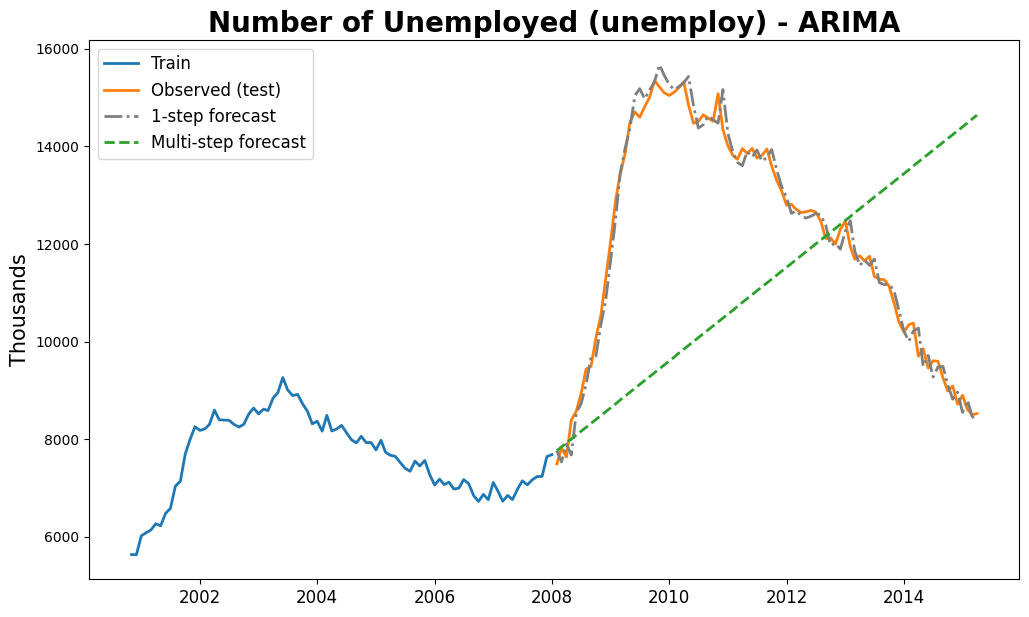

In [ ]:
print(f"Multi-step MSE: {mean_squared_error(econ_test['unemploy'].values, unemploy_multistep_forecast.values):.2f}")
print(f"Multi-step MAE: {mean_absolute_error(econ_test['unemploy'].values, unemploy_multistep_forecast.values):.2f}")
print(f"Multi-step MAPE: {mean_absolute_percentage_error(econ_test['unemploy'].values, unemploy_multistep_forecast.values):.2f}")
print()
print(f"1-step MSE: {unemploy_mse:.2f}")
print(f"1-step MAE: {unemploy_mae:.2f}")
print(f"1-step MAPE: {unemploy_mape:.2f}")

plt.figure(figsize=(12,7))
plt.plot(econ_train['unemploy'][400:], label="Train", lw=2)
plt.plot(econ_test['unemploy'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(unemploy_realtime_forecast, label="1-step forecast", c="tab:gray", ls="-.", lw=2)
plt.plot(unemploy_multistep_forecast, label="Multi-step forecast", c="tab:green", ls="--", lw=2)
plt.ylabel("Thousands", fontsize=15)
plt.title("Number of Unemployed (unemploy) - ARIMA", fontsize=20, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

## **ARIMAX - ARIMA WITH EXOGENOUS VARIABLES**

In [ ]:
# Ranking ARIMAX
def rankingOrdersARIMAX(endog, exog, max_q, max_p, diff, min_q=0, min_p=0, criterion='bic', top=10):
  aics = []
  bics = []
  cands = []

  for p in range(min_p, max_p+1):
    for q in range(min_q, max_q+1):
      mdl = ARIMA(endog=endog, exog=exog, order=(p, diff, q), freq='MS', missing='drop').fit(method_kwargs={'maxiter':2000})
      cands.append((p, diff, q))
      aics.append(mdl.aic)
      bics.append(mdl.bic)

  rankings = pd.DataFrame({
      'Orders': cands,
      'AIC': aics,
      'BIC': bics
  })
  rankings = rankings.set_index('Orders')
  rankings = rankings.sort_values(by=criterion.upper(), ascending=True)

  return rankings.head(top)


def forecast_metric(y_true, y_forecast, showall=False):
  mse = round(mean_squared_error(y_true, y_forecast), 4)
  mae = round(mean_absolute_error(y_true, y_forecast), 4)
  mape = round(mean_absolute_percentage_error(y_true, y_forecast), 4)

  if (showall == True):
    print( f"""
    =================================
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    MAPE: {mape:.4f}
    =================================
    """)

def visualize_forecast(colname, forecast_set, caption):
  plt.figure(figsize=(12,7))
  plt.plot(econ_train[colname][400:], label="Train", lw=2)
  plt.plot(econ_test[colname], label="Observed (test)", c="tab:orange", lw=2)
  plt.plot(forecast_set, label="Multi-step forecast", c="tab:green", ls="--", lw=2)
  plt.title(caption, fontsize=20, fontweight="bold")
  plt.xticks(fontsize=12)
  plt.legend(fontsize=12)
  plt.show()

### **Personal Savings Rate**

In [ ]:
psavert_exog = ['pop', 'pce', 'uempmed', 'unemploy']

In [ ]:
rankingOrdersARIMAX(endog=econ_train['psavert'], exog=econ_train[psavert_exog], max_q=5, max_p=5, diff=1)

,AIC,BIC
Orders,,
"(3, 1, 0)",921.932244,955.421913
"(0, 1, 2)",927.689964,956.993425
"(0, 1, 1)",933.153667,958.270919
"(0, 1, 4)",922.582477,960.258355
"(1, 1, 1)",932.234796,961.538256
"(3, 1, 1)",924.835267,962.511145
"(0, 1, 3)",929.247281,962.736950
"(2, 1, 0)",933.783309,963.086770
"(1, 1, 2)",929.751294,963.240963


                               SARIMAX Results                                
Dep. Variable:                psavert   No. Observations:                  487
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -459.117
Date:                Sat, 09 May 2026   AIC                            932.235
Time:                        05:45:08   BIC                            961.538
Sample:                    07-01-1967   HQIC                           943.747
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
pop            0.0006      0.000      4.549      0.000       0.000       0.001
pce           -0.0076      0.001     -7.852      0.000      -0.010      -0.006
uempmed        0.0228      0.065      0.350      0.7

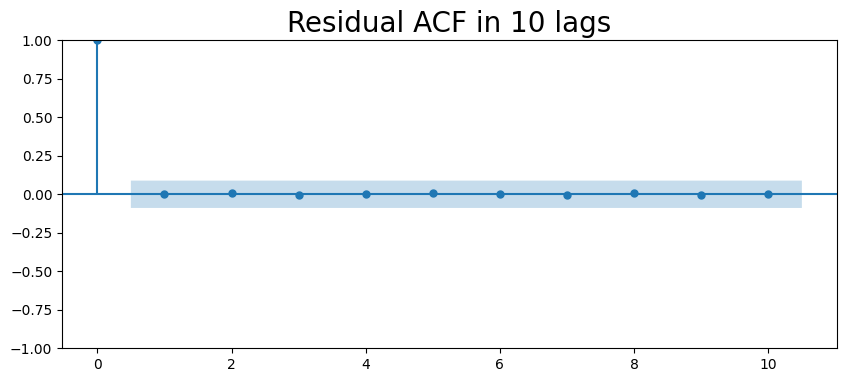

In [ ]:
arimax_psavert = ARIMA(endog=econ_train['psavert'], exog=econ_train[psavert_exog], order=(1, 1, 1), freq='MS').fit(method_kwargs={'maxiter':2000})

print(arimax_psavert.summary())
print(np.mean(arimax_psavert.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(arimax_psavert.resid, lags=10, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

date
2008-02-01    3.805931
2008-03-01    3.516659
2008-04-01    3.348227
2008-05-01    2.998835
2008-06-01    2.750171
Name: predicted_mean, dtype: float64

    MSE: 29.7199
    MAE: 4.3272
    MAPE: 0.5926
    


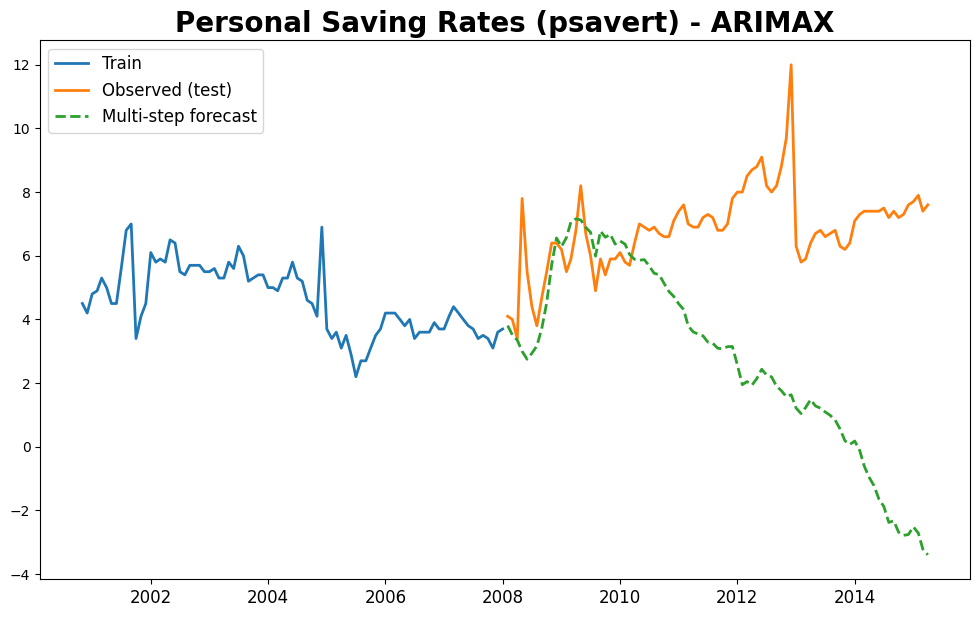

In [ ]:
arimax_psavert_pred = pd.Series(
    arimax_psavert.predict(start=econ_test.index[0], end=econ_test.index[-1], exog=econ_test[psavert_exog]),
    index = econ_test.index
)

print(arimax_psavert_pred.head())

forecast_metric(econ_test['psavert'], arimax_psavert_pred, showall=True)

visualize_forecast('psavert', arimax_psavert_pred, "Personal Saving Rates (psavert) - ARIMAX")

### **Median Duration of Unemployment**

In [ ]:
uempmed_exog = ['pop', 'pce', 'psavert', 'unemploy']

In [ ]:
rankingOrdersARIMAX(endog=econ_train['uempmed'], exog=econ_train[uempmed_exog], max_q=5, max_p=5, diff=1)

,AIC,BIC
Orders,,
"(0, 1, 1)",539.114740,564.231991
"(1, 1, 1)",539.179277,568.482737
"(0, 1, 2)",540.634871,569.938331
"(2, 1, 0)",543.746784,573.050244
"(3, 1, 0)",539.850827,573.340496
"(2, 1, 1)",541.187225,574.676894
"(0, 1, 3)",541.453520,574.943189
"(1, 1, 2)",542.635489,576.125158
"(0, 1, 4)",540.942428,578.618306


                               SARIMAX Results                                
Dep. Variable:                uempmed   No. Observations:                  487
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -262.590
Date:                Sat, 09 May 2026   AIC                            539.179
Time:                        05:45:28   BIC                            568.483
Sample:                    07-01-1967   HQIC                           550.692
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
pop            0.0001      0.000      1.085      0.278    -9.4e-05       0.000
pce           -0.0010      0.001     -1.069      0.285      -0.003       0.001
psavert        0.0114      0.027      0.432      0.6

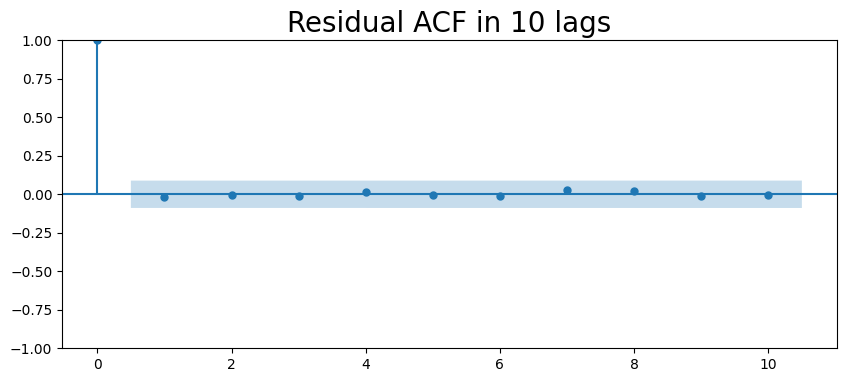

In [ ]:
arimax_uempmed = ARIMA(endog=econ_train['uempmed'], exog=econ_train[uempmed_exog], order=(1,1,1), freq='MS').fit(method_kwargs={'maxiter':2000})

print(arimax_uempmed.summary())
print(np.mean(arimax_uempmed.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(arimax_uempmed.resid, lags=10, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

date
2008-02-01    8.801412
2008-03-01    8.919818
2008-04-01    8.809401
2008-05-01    9.191846
2008-06-01    9.225095
Name: predicted_mean, dtype: float64

    MSE: 42.2843
    MAE: 5.6777
    MAPE: 0.3081
    


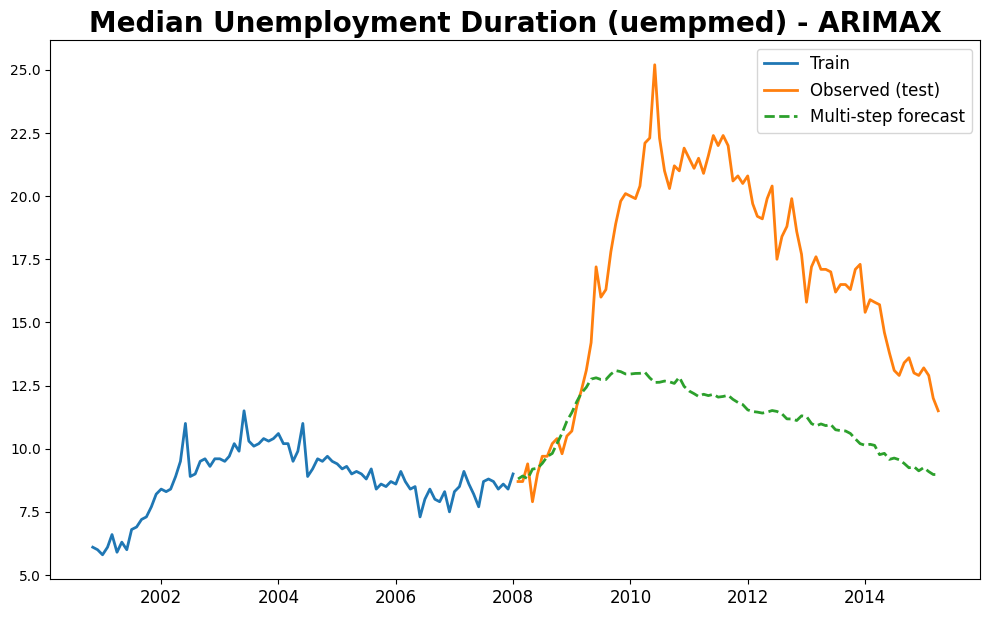

In [ ]:
arimax_uempmed_pred = pd.Series(
    arimax_uempmed.predict(start=econ_test.index[0], end=econ_test.index[-1], exog=econ_test[uempmed_exog]),
    index = econ_test.index
)
print(arimax_uempmed_pred.head())

forecast_metric(econ_test['uempmed'], arimax_uempmed_pred, showall=True)

visualize_forecast('uempmed', arimax_uempmed_pred, "Median Unemployment Duration (uempmed) - ARIMAX")

### **Number of Unemployed**

In [ ]:
unemploy_exog = ['pop', 'pce', 'psavert', 'uempmed']

In [ ]:
rankingOrdersARIMAX(endog=econ_train['unemploy'], exog=econ_train[unemploy_exog], max_q=5, max_p=5, diff=2)

,AIC,BIC
Orders,,
"(2, 2, 3)",6437.232830,6479.074319
"(1, 2, 4)",6437.308133,6479.149622
"(4, 2, 1)",6438.849095,6480.690584
"(1, 2, 1)",6453.022016,6482.311058
"(0, 2, 2)",6453.244249,6482.533291
"(3, 2, 5)",6428.612080,6483.006015
"(3, 2, 1)",6445.559476,6483.216816
"(4, 2, 2)",6439.410743,6485.436380
"(0, 2, 1)",6460.682657,6485.787550


                               SARIMAX Results                                
Dep. Variable:               unemploy   No. Observations:                  487
Model:                 ARIMA(0, 2, 1)   Log Likelihood               -3224.341
Date:                Sat, 09 May 2026   AIC                           6460.683
Time:                        05:45:43   BIC                           6485.788
Sample:                    07-01-1967   HQIC                          6470.547
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
pop            0.0143      0.067      0.213      0.831      -0.117       0.145
pce            0.3342      0.415      0.805      0.421      -0.480       1.148
psavert        2.9192     11.199      0.261      0.7

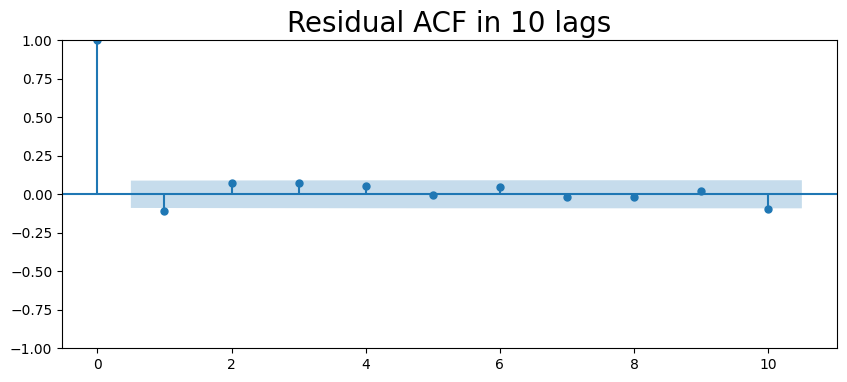

In [ ]:
arimax_unemploy = ARIMA(endog=econ_train['unemploy'], exog=econ_train[unemploy_exog], order=(0,2,1), freq='MS').fit(method_kwargs={'maxiter':2000})

print(arimax_unemploy.summary())
print(np.mean(arimax_unemploy.resid))
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(arimax_unemploy.resid, lags=10, ax=ax)
plt.title("Residual ACF in 10 lags", fontsize=20)
plt.show()

date
2008-02-01    7749.297923
2008-03-01    7832.900493
2008-04-01    7912.298798
2008-05-01    8013.006820
2008-06-01    8093.311967
Name: predicted_mean, dtype: float64

    MSE: 13313415.1856
    MAE: 3072.2824
    MAPE: 0.2541
    


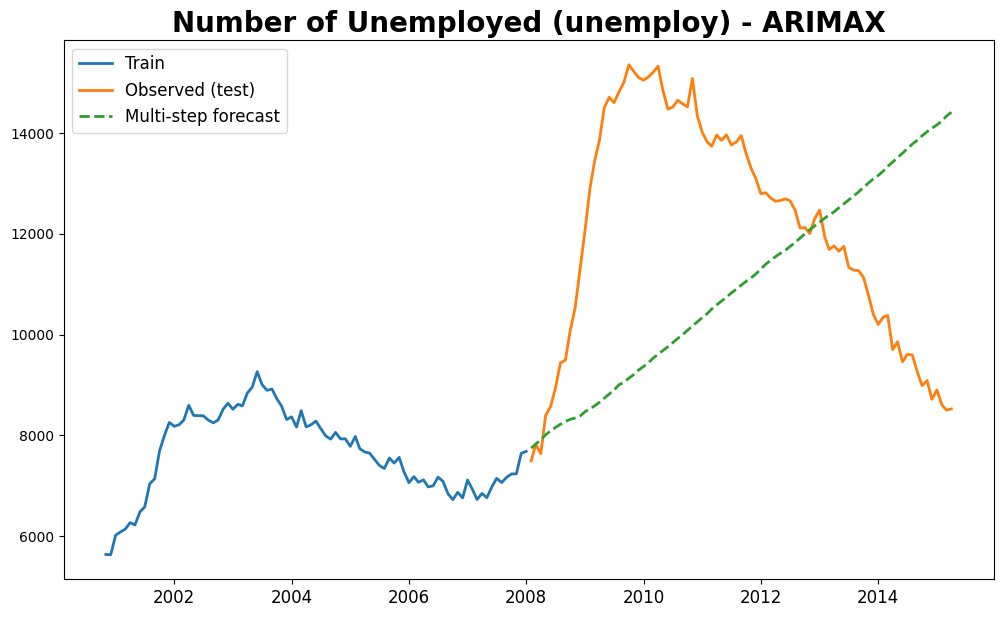

In [ ]:
arimax_unemploy_pred = pd.Series(
    arimax_unemploy.predict(start=econ_test.index[0], end=econ_test.index[-1], exog=econ_test[unemploy_exog]),
    index = econ_test.index
)
print(arimax_unemploy_pred.head())

forecast_metric(econ_test['unemploy'], arimax_unemploy_pred, showall=True)

visualize_forecast('unemploy', arimax_unemploy_pred, "Number of Unemployed (unemploy) - ARIMAX")

## **AGGREGATED FIGURES**

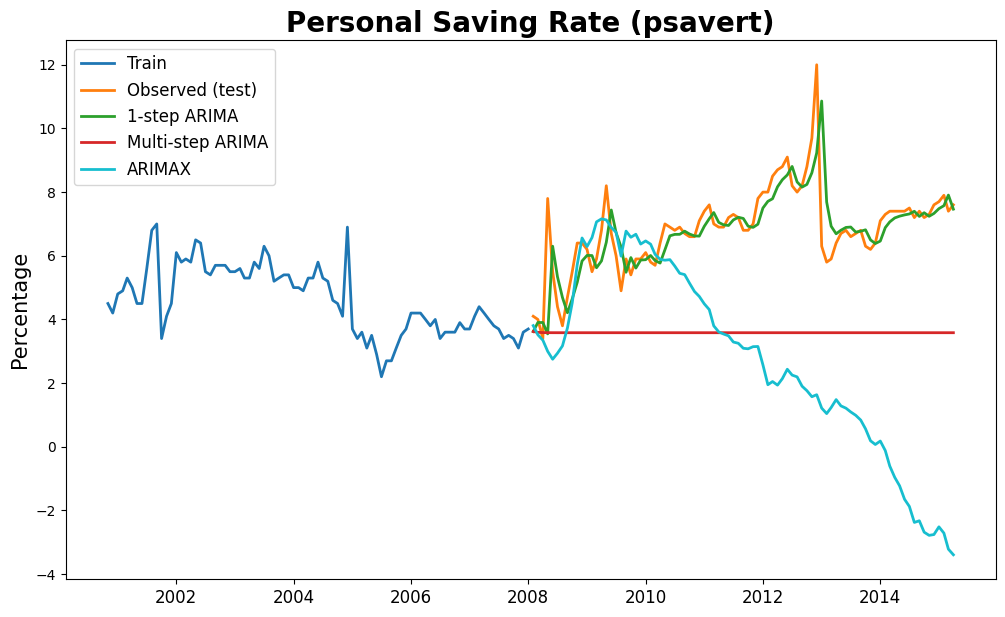

In [ ]:
plt.figure(figsize=(12,7))
plt.plot(econ_train['psavert'][400:], label="Train", lw=2)
plt.plot(econ_test['psavert'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(psavert_realtime_forecast, label="1-step ARIMA", c="tab:green", lw=2)
plt.plot(psavert_multistep_forecast, label="Multi-step ARIMA", c="tab:red", lw=2)
plt.plot(arimax_psavert_pred, label="ARIMAX", c="tab:cyan", lw=2)
plt.ylabel("Percentage", fontsize=15)
plt.title("Personal Saving Rate (psavert)", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

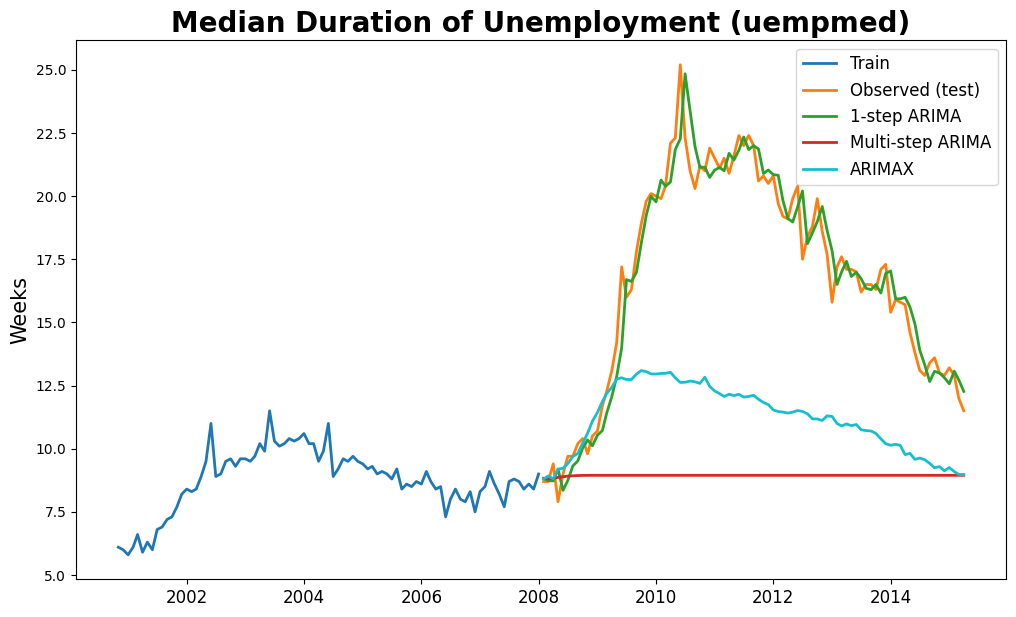

In [ ]:
plt.figure(figsize=(12,7))
plt.plot(econ_train['uempmed'][400:], label="Train", lw=2)
plt.plot(econ_test['uempmed'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(uempmed_realtime_forecast, label="1-step ARIMA", c="tab:green", lw=2)
plt.plot(uempmed_multistep_forecast, label="Multi-step ARIMA", c="tab:red", lw=2)
plt.plot(arimax_uempmed_pred, label="ARIMAX", c="tab:cyan", lw=2)
plt.ylabel("Weeks", fontsize=15)
plt.title("Median Duration of Unemployment (uempmed)", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

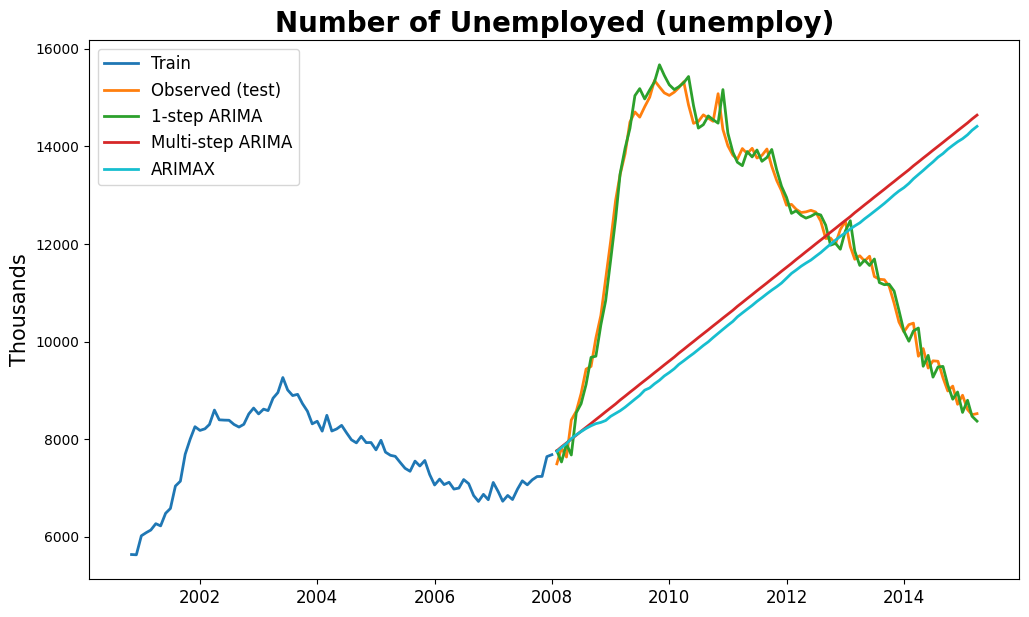

In [ ]:
plt.figure(figsize=(12,7))
plt.plot(econ_train['unemploy'][400:], label="Train", lw=2)
plt.plot(econ_test['unemploy'], label="Observed (test)", c="tab:orange", lw=2)
plt.plot(unemploy_realtime_forecast, label="1-step ARIMA", c="tab:green", lw=2)
plt.plot(unemploy_multistep_forecast, label="Multi-step ARIMA", c="tab:red", lw=2)
plt.plot(arimax_unemploy_pred, label="ARIMAX", c="tab:cyan", lw=2)
plt.ylabel("Thousands", fontsize=15)
plt.title("Number of Unemployed (unemploy)", fontsize=20, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()